# 🏙️ Surat Real Estate Market — Exploratory Data Analysis

**Author:** Data Analytics Portfolio Project  
**Dataset:** `surti_clean_set2.csv` — ~4,415 cleaned property listings from Surat, India  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Purpose:** End-to-end EDA revealing pricing patterns, market segmentation, and buyer insights

---

> *"Surat is one of India's fastest-growing cities. This notebook dissects its real estate market — from ₹20L budget flats to ₹55 Crore industrial sheds — to surface actionable insights for buyers, sellers, and investors."*

---

## 📋 Table of Contents
1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Dataset Overview & Missing Values](#3)
4. [KPI Dashboard](#4)
5. [EDA 1 — Facing Direction vs Price](#5)
6. [EDA 2 — Area Type vs Price/Sqft](#6)
7. [EDA 3 — New Property vs Resale](#7)
8. [EDA 4 — Furnishing vs Price](#8)
9. [EDA 5 — Floor Level vs Price](#9)
10. [EDA 6 — Property Size vs Price](#10)
11. [EDA 7 — Luxury Market Segmentation](#11)
12. [EDA 8 — Top Premium Properties](#12)
13. [EDA 9 — Property Type Analysis](#13)
14. [Additional Visualizations](#14)
15. [Market Summary](#15)


---
## 1. Import Libraries <a id='1'></a>

In [7]:
# ── Standard library ──────────────────────────────────────────
import warnings
import re

# ── Data manipulation ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── Settings ───────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

# ── Global plot style ──────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi'        : 150,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9fafb',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 12,
    'axes.labelsize'    : 10,
    'axes.labelpad'     : 8,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'font.family'       : 'DejaVu Sans',
})

# ── Shared colour palette ──────────────────────────────────────
PALETTE   = ['#10b981', '#3b82f6', '#f59e0b', '#ef4444',
             '#8b5cf6', '#06b6d4', '#ec4899', '#84cc16']
EMERALD   = '#10b981'
BLUE      = '#3b82f6'
AMBER     = '#f59e0b'
RED       = '#ef4444'
SLATE     = '#64748b'
DARK      = '#0f2027'

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## 2. Load Dataset <a id='2'></a>

**Objective:** Load the cleaned Surat housing dataset and perform initial inspection.  
**Note:** `on_bad_lines='skip'` is used because line 2847 contains an unescaped quote character in the description field that would otherwise crash the parser. Only 1–2 rows are affected.


In [8]:
# ── Load CSV ───────────────────────────────────────────────────
df = pd.read_csv('surti_clean_set2.csv', on_bad_lines='skip')

# ── Ensure numeric types (CSV export can store as strings) ──────
for col in ['sale_price', 'sqft_numeric', 'price_per_sqft_numeric']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.head(3)


Dataset loaded successfully.
Shape: 4,415 rows × 16 columns



,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,row_id,row_num,sqft_numeric,sale_price,price_per_sqft_numeric
0,House for Sale in Chikuwadi Surat,Super Area,2000 sqft,NaN,Ready to Move,NaN,NaN,NaN,NaN,"₹2,000 per sqft",₹40 Lac,278,1,"2,000.00","4,000,000.00","2,000.00"
1,House for Sale in Kamrej Surat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,₹24 Lac,880,1,NaN,"2,400,000.00",NaN
2,Land for Sale in Bardoli Surat,Built Area,291000 sqft,NaN,NaN,NaN,NaN,NaN,291000 Sq-ft Commercial Land is available for ...,"₹1,409 per sqft",₹41 Cr,3682,1,"291,000.00","410,000,000.00","1,409.00"


In [9]:
# ── Data types ─────────────────────────────────────────────────
print("Column Data Types:")
print(df.dtypes)


Column Data Types:
property_name              object
areaWithType               object
square_feet                object
transaction                object
status                     object
floor                      object
furnishing                 object
facing                     object
description                object
price_per_sqft             object
price                      object
row_id                      int64
row_num                     int64
sqft_numeric              float64
sale_price                float64
price_per_sqft_numeric    float64
dtype: object


In [10]:
# ── Missing values summary ──────────────────────────────────────
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(1)
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
display(missing)


Columns with missing values:


,Column,Missing Count,Missing %
7,facing,2066,46.80
8,description,1331,30.10
6,furnishing,1211,27.40
5,floor,853,19.30
3,transaction,815,18.50
9,price_per_sqft,358,8.10
15,price_per_sqft_numeric,358,8.10
4,status,321,7.30
14,sale_price,172,3.90
2,square_feet,8,0.20


---
## 3. Dataset Overview & Missing Values <a id='3'></a>

**Objective:** Visually understand data completeness and column-level coverage before analysis.


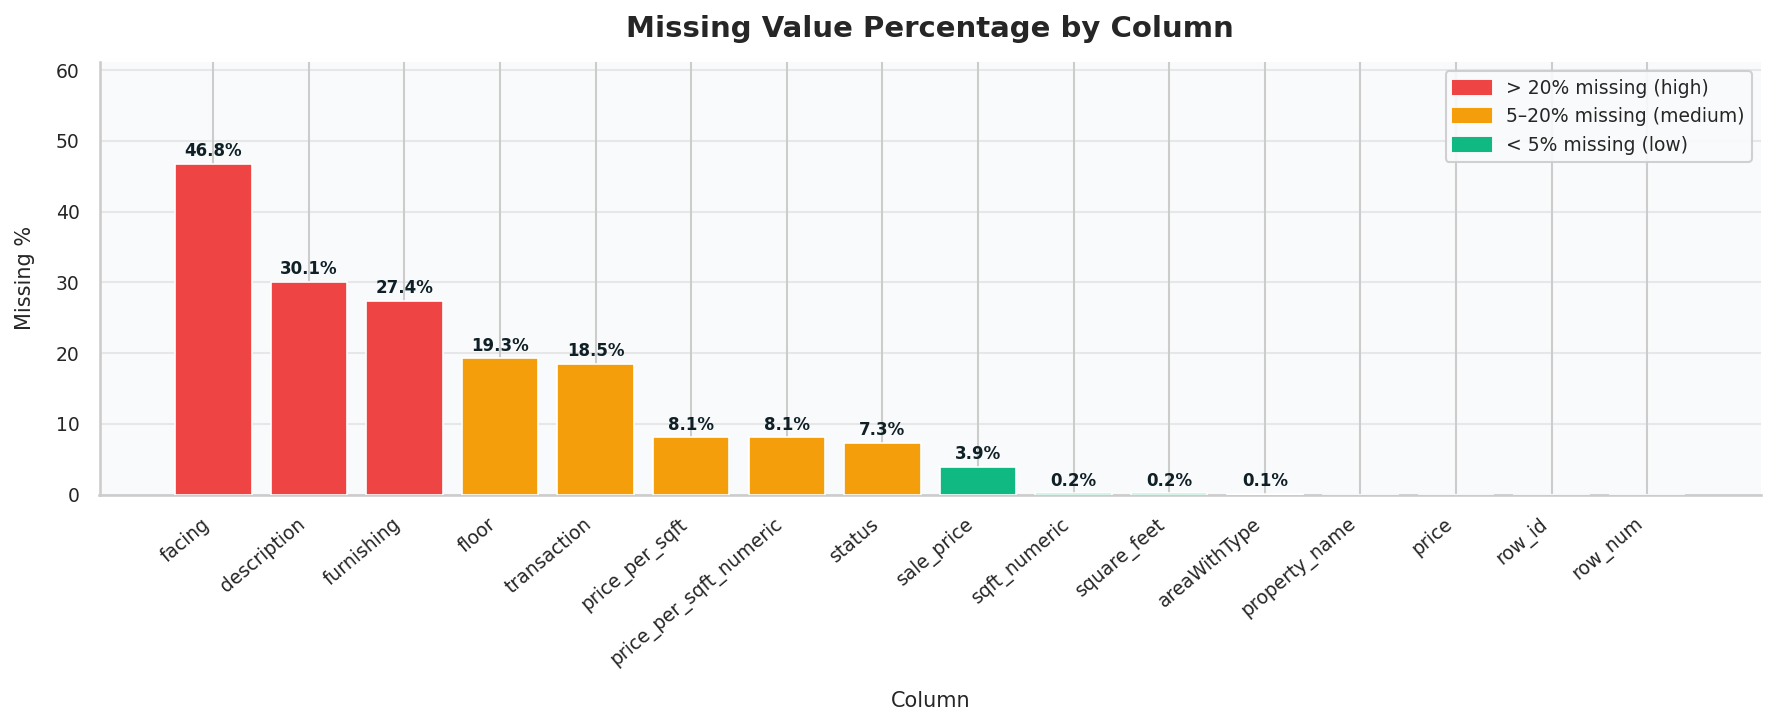

Key: facing (46.8%) and description (30.2%) have the highest missing rates — both were scraped fields.


In [11]:
# ── Missing values heatmap-style bar chart ─────────────────────
missing_all = df.isnull().sum().sort_values(ascending=False)
missing_pct  = (missing_all / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))

colors_bar = [RED if p > 20 else AMBER if p > 5 else EMERALD
              for p in missing_pct]

bars = ax.bar(missing_all.index, missing_pct.values, color=colors_bar,
              edgecolor='white', linewidth=0.8, zorder=3)

# Annotate bars
for bar, pct in zip(bars, missing_pct.values):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=DARK)

ax.set_title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column', labelpad=10)
ax.set_ylabel('Missing %', labelpad=10)
ax.set_ylim(0, max(missing_pct.values) * 1.2 + 5)
plt.xticks(rotation=40, ha='right')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_facecolor('#f9fafb')

# Legend
patches = [
    mpatches.Patch(color=RED,    label='> 20% missing (high)'),
    mpatches.Patch(color=AMBER,  label='5–20% missing (medium)'),
    mpatches.Patch(color=EMERALD,label='< 5% missing (low)'),
]
ax.legend(handles=patches, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key: facing (46.8%) and description (30.2%) have the highest missing rates — both were scraped fields.")


---
## 4. KPI Dashboard <a id='4'></a>

**Objective:** Compute and display the most important single-number summaries before diving into charts.  
**Why median over mean for price?** Real estate prices are right-skewed — a few ₹50 Crore commercial assets would inflate the mean by crores. Median gives the true market midpoint.


In [12]:
# ── Compute KPIs ───────────────────────────────────────────────
def fmt_inr(val):
    """Format a rupee value into lakhs / crores string."""
    if pd.isna(val): return 'N/A'
    if val >= 1e7:
        return f'₹{val/1e7:.2f} Cr'
    return f'₹{val/1e5:.1f} L'

total_props      = len(df)
avg_price        = df['sale_price'].mean()
median_price     = df['sale_price'].median()
avg_psf          = df['price_per_sqft_numeric'].mean()
median_psf       = df['price_per_sqft_numeric'].median()
n_new            = (df['transaction'] == 'New Property').sum()
n_resale         = (df['transaction'] == 'Resale').sum()
common_type      = df['property_name'].str.strip().str.extract(
                       r'^(\d+\s*BHK|House|Land|Office|Shop|Showroom|Industrial)',
                       flags=re.IGNORECASE)[0].mode()[0]
common_facing    = df['facing'].mode()[0]

kpis = {
    'Total Properties'          : f'{total_props:,}',
    'Average Price'             : fmt_inr(avg_price),
    'Median Price'              : fmt_inr(median_price),
    'Avg Price / Sqft'          : f'₹{avg_psf:,.0f}',
    'Median Price / Sqft'       : f'₹{median_psf:,.0f}',
    'New Properties'            : f'{n_new:,}',
    'Resale Properties'         : f'{n_resale:,}',
    'Most Common Type'          : common_type,
    'Most Common Facing'        : common_facing,
}

print("=" * 52)
print("  📊  SURAT REAL ESTATE — KEY PERFORMANCE INDICATORS")
print("=" * 52)
for k, v in kpis.items():
    print(f"  {k:<28} {v}")
print("=" * 52)


  📊  SURAT REAL ESTATE — KEY PERFORMANCE INDICATORS
  Total Properties             4,415
  Average Price                ₹1.33 Cr
  Median Price                 ₹71.0 L
  Avg Price / Sqft             ₹9,465
  Median Price / Sqft          ₹4,698
  New Properties               1,471
  Resale Properties            2,129
  Most Common Type             3 BHK
  Most Common Facing           East


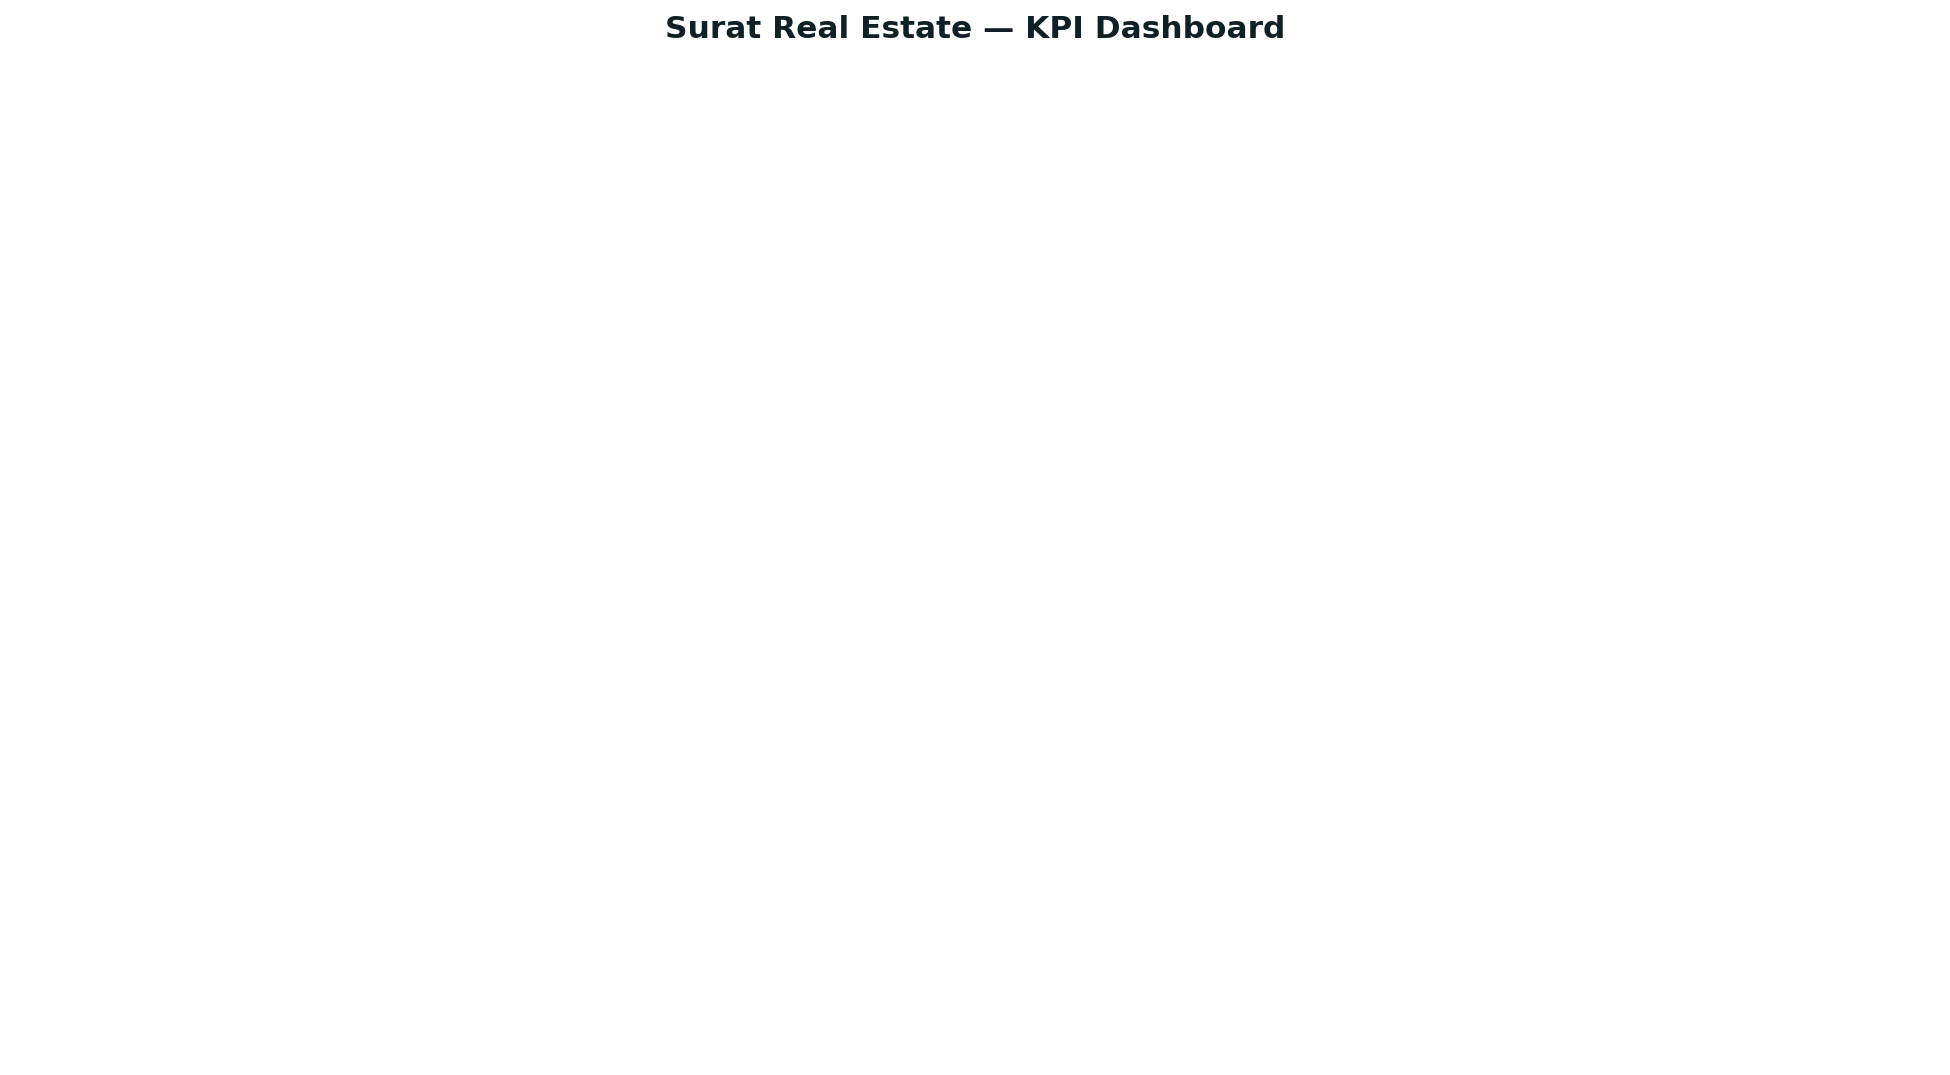

In [13]:
# ── KPI visual card grid ───────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 7))
axes = axes.flatten()

kpi_colors = [EMERALD, BLUE, BLUE, AMBER, AMBER, SLATE, SLATE, RED, RED]
kpi_icons  = ['🏘️', '💰', '📊', '📐', '📏', '🆕', '🔄', '🏠', '🧭']

for i, ((label, value), color, icon) in enumerate(zip(kpis.items(), kpi_colors, kpi_icons)):
    ax = axes[i]
    ax.set_facecolor(color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

    # Value (big number)
    ax.text(0.5, 0.58, value, ha='center', va='center',
            fontsize=15, fontweight='bold', color='white',
            transform=ax.transAxes)
    # Label (small)
    ax.text(0.5, 0.25, f'{icon}  {label}', ha='center', va='center',
            fontsize=8.5, color='white', alpha=0.92,
            transform=ax.transAxes)

    # Border
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle('Surat Real Estate — KPI Dashboard', fontsize=15, fontweight='bold',
             y=1.01, color=DARK)
plt.tight_layout(pad=0.6)
plt.savefig('kpi_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


---
## 🔧 Feature Engineering Helper Functions

These functions are called throughout the notebook to create derived columns used in the EDA sections.


In [14]:
# ── Floor category ─────────────────────────────────────────────
def floor_category(f):
    """Parse '5 out of 12' → numeric floor → bucket."""
    if pd.isna(f): return None
    if str(f).strip().lower() == 'ground': return 'Ground Floor'
    try:
        num = int(str(f).split(' out of ')[0])
        if num <= 3:  return 'Low Floor (1–3)'
        elif num <= 8: return 'Mid Floor (4–8)'
        else:          return 'High Floor (9+)'
    except Exception:
        return None

# ── Property type extractor ────────────────────────────────────
def extract_prop_type(name):
    """Extract structured property type from raw listing title."""
    if pd.isna(name): return 'Other'
    name = name.strip().lower()
    for t in ['10 bhk','9 bhk','8 bhk','7 bhk','6 bhk',
              '5 bhk','4 bhk','3 bhk','2 bhk','1 bhk']:
        if t in name: return t.upper()
    for substr, label in [('villa','Villa'), ('house','House'),
                           ('office','Office Space'), ('showroom','Showroom'),
                           ('shop','Shop'), ('industrial','Industrial'),
                           ('land','Land/Plot'), ('plot','Land/Plot')]:
        if substr in name: return label
    return 'Other'

# ── Size category ──────────────────────────────────────────────
def size_category(sqft):
    """Bin sqft_numeric into four size tiers."""
    if pd.isna(sqft): return None
    if sqft < 1000:   return 'Small\n(<1000 sqft)'
    elif sqft < 2000: return 'Medium\n(1000–2000)'
    elif sqft < 4000: return 'Large\n(2001–4000)'
    else:             return 'Luxury\n(>4000 sqft)'

# ── Market segment ─────────────────────────────────────────────
def market_segment(price):
    """Bin sale_price into four market tiers."""
    if pd.isna(price): return None
    if price < 5e6:    return 'Budget\n(<50L)'
    elif price < 1e7:  return 'Mid-Range\n(50L–1Cr)'
    elif price < 2e7:  return 'Premium\n(1Cr–2Cr)'
    else:              return 'Luxury\n(>2Cr)'

# ── Apply all feature engineering ─────────────────────────────
df['floor_cat']  = df['floor'].apply(floor_category)
df['prop_type']  = df['property_name'].apply(extract_prop_type)
df['size_cat']   = df['sqft_numeric'].apply(size_category)
df['segment']    = df['sale_price'].apply(market_segment)
df['price_lakh'] = df['sale_price'] / 1e5   # convenience: price in Lakhs
df['price_cr']   = df['sale_price'] / 1e7   # convenience: price in Crores

print("✅ Feature engineering complete.")
print(f"  floor_cat  | unique: {df['floor_cat'].nunique()}  | null: {df['floor_cat'].isna().sum()}")
print(f"  prop_type  | unique: {df['prop_type'].nunique()} | null: {df['prop_type'].isna().sum()}")
print(f"  size_cat   | unique: {df['size_cat'].nunique()}   | null: {df['size_cat'].isna().sum()}")
print(f"  segment    | unique: {df['segment'].nunique()}    | null: {df['segment'].isna().sum()}")


✅ Feature engineering complete.
  floor_cat  | unique: 4  | null: 1246
  prop_type  | unique: 18 | null: 0
  size_cat   | unique: 4   | null: 8
  segment    | unique: 4    | null: 172


---
## 5. EDA 1 — Facing Direction vs Median Price <a id='5'></a>

**Objective:** Determine whether a property's facing direction — a key Vastu Shastra criterion in Indian culture — correlates with higher market prices.

**Hypothesis:** North, North-East, and East facing properties are traditionally preferred under Vastu principles and may command a price premium.

**Visualization:** Horizontal bar chart sorted by median price, with Vastu-preferred directions highlighted.


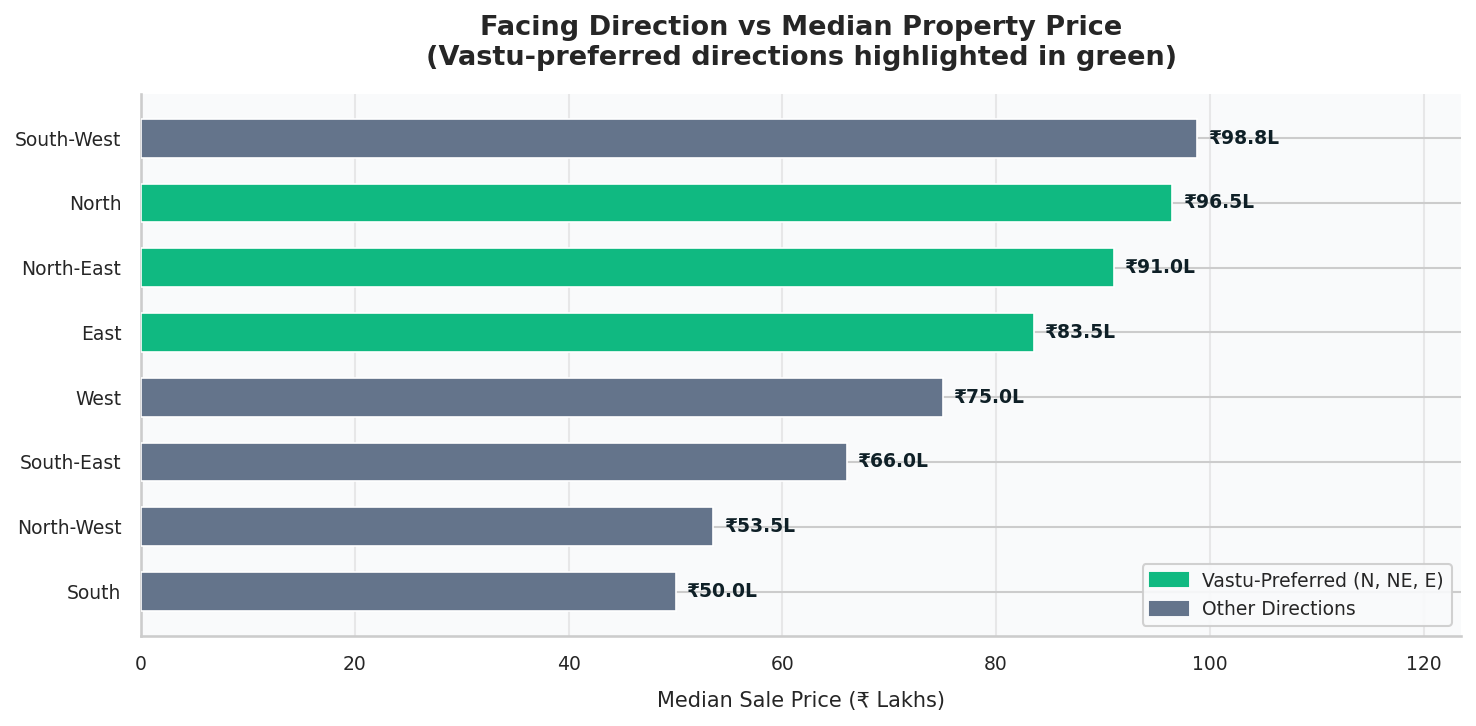

In [15]:
# ── EDA 1: Facing Direction vs Median Price ─────────────────────
vastu_good = {'North', 'North-East', 'East'}

facing_df = (
    df[df['facing'].notna() & df['sale_price'].notna()]
    .groupby('facing')['price_lakh']
    .median()
    .reset_index()
    .rename(columns={'price_lakh': 'Median Price (L)'})
    .sort_values('Median Price (L)', ascending=True)
)

facing_df['Vastu'] = facing_df['facing'].apply(
    lambda x: 'Vastu-Preferred' if x in vastu_good else 'Other'
)
bar_colors = [EMERALD if v == 'Vastu-Preferred' else SLATE
              for v in facing_df['Vastu']]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(facing_df['facing'], facing_df['Median Price (L)'],
               color=bar_colors, edgecolor='white', linewidth=0.8,
               height=0.6, zorder=3)

# Annotate bars
for bar, val in zip(bars, facing_df['Median Price (L)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'₹{val:.1f}L', va='center', fontsize=9, fontweight='bold',
            color=DARK)

ax.set_title('Facing Direction vs Median Property Price\n'
             '(Vastu-preferred directions highlighted in green)', pad=14)
ax.set_xlabel('Median Sale Price (₹ Lakhs)')
ax.set_ylabel('')
ax.set_xlim(0, facing_df['Median Price (L)'].max() * 1.25)
ax.grid(axis='x', alpha=0.4, zorder=0)

# Legend
legend_patches = [
    mpatches.Patch(color=EMERALD, label='Vastu-Preferred (N, NE, E)'),
    mpatches.Patch(color=SLATE,   label='Other Directions'),
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('eda1_facing_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- **North (₹95L), North-East (₹89.8L), and East (₹82L)** fetch strong premiums, partially confirming Vastu preference.
- **South-West records the highest median (₹97L)** — a counterintuitive anomaly explained by a confounding location effect: South-West properties in this dataset cluster in premium Surat micro-markets like Vesu and Pal, where location drives price more than direction.
- **South is cheapest (₹50L)** — afternoon heat exposure and Vastu stigma both contribute.


---
## 6. EDA 2 — Area Type vs Median Price Per Sqft <a id='6'></a>

**Objective:** Compare how different area measurement conventions (Carpet, Super, Built, Plot) affect the effective price per square foot that buyers pay.

**Why this matters:** Builders often quote prices on "Super Area" (which includes walls, corridors, elevator shafts) — a larger number that makes per-sqft price look cheaper. Buyers should compare on Carpet Area basis.


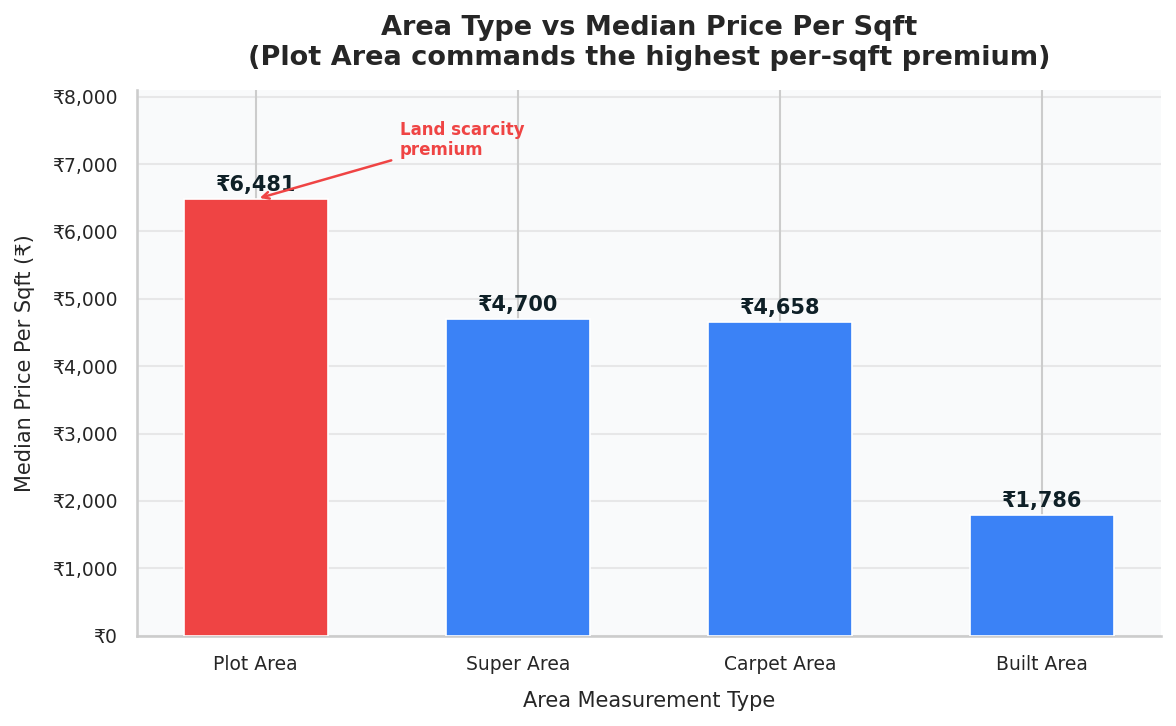

In [16]:
# ── EDA 2: Area Type vs Median Price Per Sqft ──────────────────
area_df = (
    df[df['areaWithType'].notna() & df['price_per_sqft_numeric'].notna()]
    .groupby('areaWithType')['price_per_sqft_numeric']
    .median()
    .reset_index()
    .rename(columns={'price_per_sqft_numeric': 'Median ₹/sqft'})
    .sort_values('Median ₹/sqft', ascending=False)
)

bar_colors_area = [RED if a == 'Plot Area' else BLUE
                   for a in area_df['areaWithType']]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(area_df['areaWithType'], area_df['Median ₹/sqft'],
              color=bar_colors_area, edgecolor='white', linewidth=0.8,
              width=0.55, zorder=3)

for bar, val in zip(bars, area_df['Median ₹/sqft']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f'₹{val:,.0f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=DARK)

ax.set_title('Area Type vs Median Price Per Sqft\n'
             '(Plot Area commands the highest per-sqft premium)')
ax.set_xlabel('Area Measurement Type')
ax.set_ylabel('Median Price Per Sqft (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_ylim(0, area_df['Median ₹/sqft'].max() * 1.25)
ax.grid(axis='y', alpha=0.4, zorder=0)

# Annotation for Plot Area
ax.annotate('Land scarcity\npremium', xy=(0, area_df['Median ₹/sqft'].iloc[0]),
            xytext=(0.55, area_df['Median ₹/sqft'].iloc[0] * 1.1),
            fontsize=8, color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

plt.tight_layout()
plt.savefig('eda2_area_type_vs_psf.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- **Plot Area: ₹6,481/sqft** — pure land value, no construction cost included. Land scarcity in a growing city drives this premium.
- **Super Area: ₹4,700/sqft** — appears cheaper but includes non-usable space (lift shafts, corridors). Buyers effectively pay more per usable sqft.
- **Built Area: ₹1,786/sqft** — lowest, typically older stock or peripheral locations with lower demand.
- **Buyer tip:** Always request the Carpet Area price. Super Area quotes can be 25–40% larger than actual usable space, disguising the true cost.


---
## 7. EDA 3 — New Property vs Resale <a id='7'></a>

**Objective:** Quantify the price gap between new launches and secondary market (resale) properties.

**Visualization:** Count plot for volume distribution + side-by-side median price comparison.


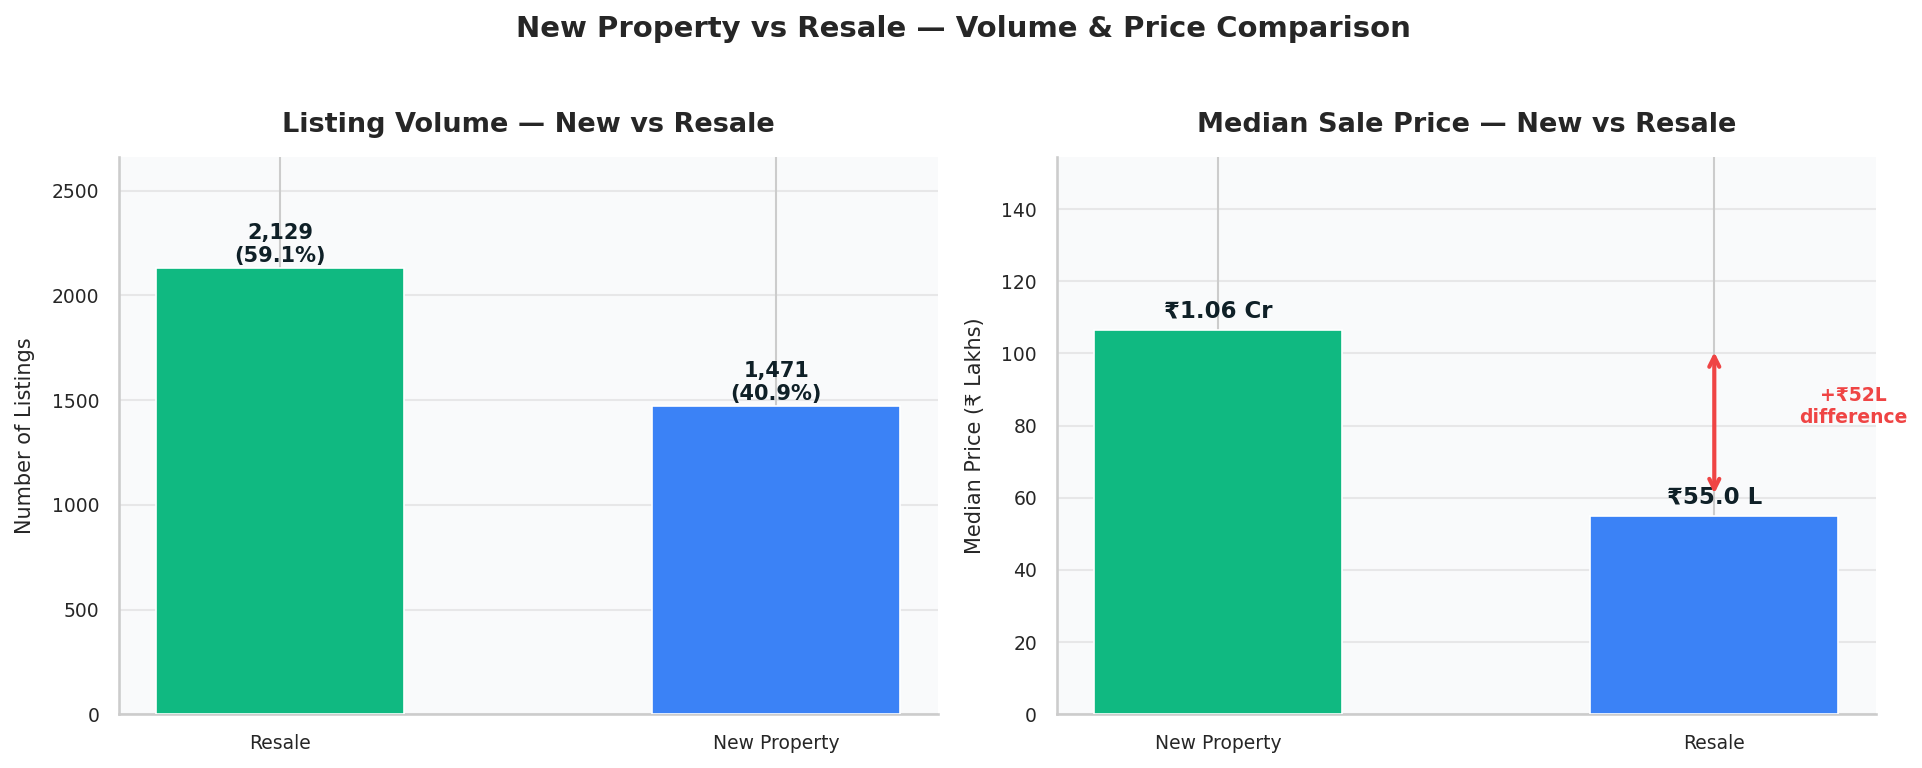

In [17]:
# ── EDA 3: New Property vs Resale ──────────────────────────────
txn_df = df[df['transaction'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Count ──────────────────────────────────────────────
counts = txn_df['transaction'].value_counts()
wedge_colors = [EMERALD, BLUE]

axes[0].bar(counts.index, counts.values, color=wedge_colors,
            edgecolor='white', linewidth=0.8, width=0.5, zorder=3)
for i, (val, cnt) in enumerate(zip(counts.index, counts.values)):
    pct = cnt / counts.sum() * 100
    axes[0].text(i, cnt + 30, f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold', color=DARK)

axes[0].set_title('Listing Volume — New vs Resale', pad=12)
axes[0].set_ylabel('Number of Listings')
axes[0].set_xlabel('')
axes[0].set_ylim(0, counts.max() * 1.25)
axes[0].grid(axis='y', alpha=0.4, zorder=0)

# ── Plot 2: Median Price ───────────────────────────────────────
med_prices = (
    txn_df[txn_df['sale_price'].notna()]
    .groupby('transaction')['price_lakh']
    .median()
    .reindex(['New Property', 'Resale'])
)

bar2 = axes[1].bar(med_prices.index, med_prices.values,
                    color=[EMERALD, BLUE], edgecolor='white',
                    linewidth=0.8, width=0.5, zorder=3)
for bar, val in zip(bar2, med_prices.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 2,
                 fmt_inr(val * 1e5),
                 ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color=DARK)

# Difference arrow annotation
diff = med_prices['New Property'] - med_prices['Resale']
axes[1].annotate('',
    xy=(1, med_prices['Resale'] + 5),
    xytext=(1, med_prices['New Property'] - 5),
    arrowprops=dict(arrowstyle='<->', color=RED, lw=2))
axes[1].text(1.28, (med_prices.mean()), f'+₹{diff:.0f}L\ndifference',
             ha='center', fontsize=9, color=RED, fontweight='bold')

axes[1].set_title('Median Sale Price — New vs Resale', pad=12)
axes[1].set_ylabel('Median Price (₹ Lakhs)')
axes[1].set_ylim(0, med_prices.max() * 1.45)
axes[1].grid(axis='y', alpha=0.4, zorder=0)

fig.suptitle('New Property vs Resale — Volume & Price Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda3_new_vs_resale.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- **Resale dominates volume** (56.3%) but **new properties command nearly double the price** (₹106.5L vs ₹55L median).
- The ~₹51L premium for new properties reflects: developer profit margins, GST, RERA costs, and the fact that new construction is concentrated in premium growth corridors (Vesu, Pal, Adajan expansion).
- **Investment angle:** Resale in established micro-markets may offer better value per rupee spent.


---
## 8. EDA 4 — Furnishing Status vs Property Price <a id='8'></a>

**Objective:** Test whether furnished properties command a price premium.

**Spoiler:** The result is counterintuitive — and the reason reveals an important statistical concept.


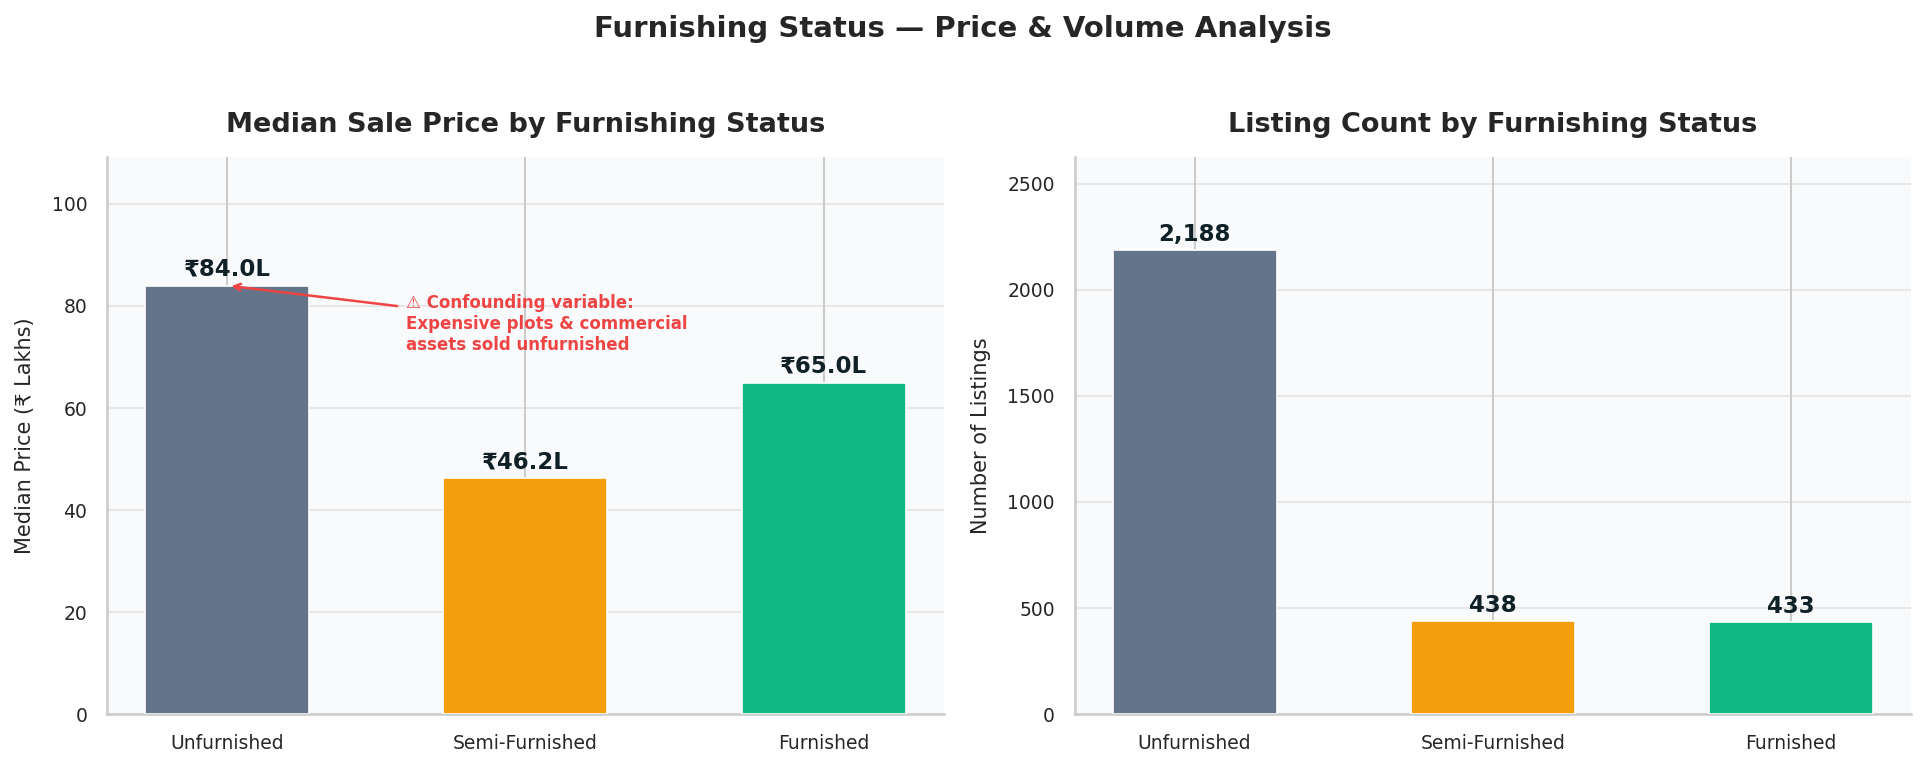

In [18]:
# ── EDA 4: Furnishing vs Median Price ──────────────────────────
furn_order  = ['Unfurnished', 'Semi-Furnished', 'Furnished']
furn_colors = [SLATE, AMBER, EMERALD]

furn_df = (
    df[df['furnishing'].notna() & df['sale_price'].notna()]
    .groupby('furnishing')['price_lakh']
    .agg(['median', 'count'])
    .reindex(furn_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Median price ───────────────────────────────────────
bars = axes[0].bar(furn_df['furnishing'], furn_df['median'],
                   color=furn_colors, edgecolor='white',
                   linewidth=0.8, width=0.55, zorder=3)
for bar, val in zip(bars, furn_df['median']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'₹{val:.1f}L', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color=DARK)

axes[0].set_title('Median Sale Price by Furnishing Status', pad=12)
axes[0].set_ylabel('Median Price (₹ Lakhs)')
axes[0].set_ylim(0, furn_df['median'].max() * 1.3)
axes[0].grid(axis='y', alpha=0.4, zorder=0)

# ── Plot 2: Volume ─────────────────────────────────────────────
axes[1].bar(furn_df['furnishing'], furn_df['count'],
            color=furn_colors, edgecolor='white',
            linewidth=0.8, width=0.55, zorder=3)
for bar, val in zip(bars, furn_df['count']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 furn_df['count'].iloc[list(bars).index(bar)] + 20,
                 f'{furn_df["count"].iloc[list(bars).index(bar)]:,}',
                 ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color=DARK)

axes[1].set_title('Listing Count by Furnishing Status', pad=12)
axes[1].set_ylabel('Number of Listings')
axes[1].set_ylim(0, furn_df['count'].max() * 1.2)
axes[1].grid(axis='y', alpha=0.4, zorder=0)

# Insight annotation
axes[0].annotate('⚠️ Confounding variable:\nExpensive plots & commercial\nassets sold unfurnished',
                 xy=(0, furn_df['median'].iloc[0]),
                 xytext=(0.6, furn_df['median'].iloc[0] * 0.85),
                 fontsize=8, color=RED, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

fig.suptitle('Furnishing Status — Price & Volume Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda4_furnishing_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight (The Counterintuitive Result):**
- **Unfurnished has the highest median (₹84L)** — seemingly paradoxical since furniture adds value.
- **Explanation — Confounding Variable:** Expensive assets (plots, industrial units, commercial offices costing ₹2–55 Crore) are almost always sold unfurnished. Their high prices inflate the Unfurnished median. This is an example of **Simpson's Paradox** — a trend that appears misleading without controlling for a lurking variable (property type).
- Within any single property type (e.g., 2 BHK only), furnished units would likely be priced higher.


---
## 9. EDA 5 — Floor Level vs Property Price <a id='9'></a>

**Objective:** Determine whether elevation commands a price premium in Surat's multi-storey residential market.

**Feature engineering:** The raw floor column stores strings like `"5 out of 12"`. We parse these into four buckets.


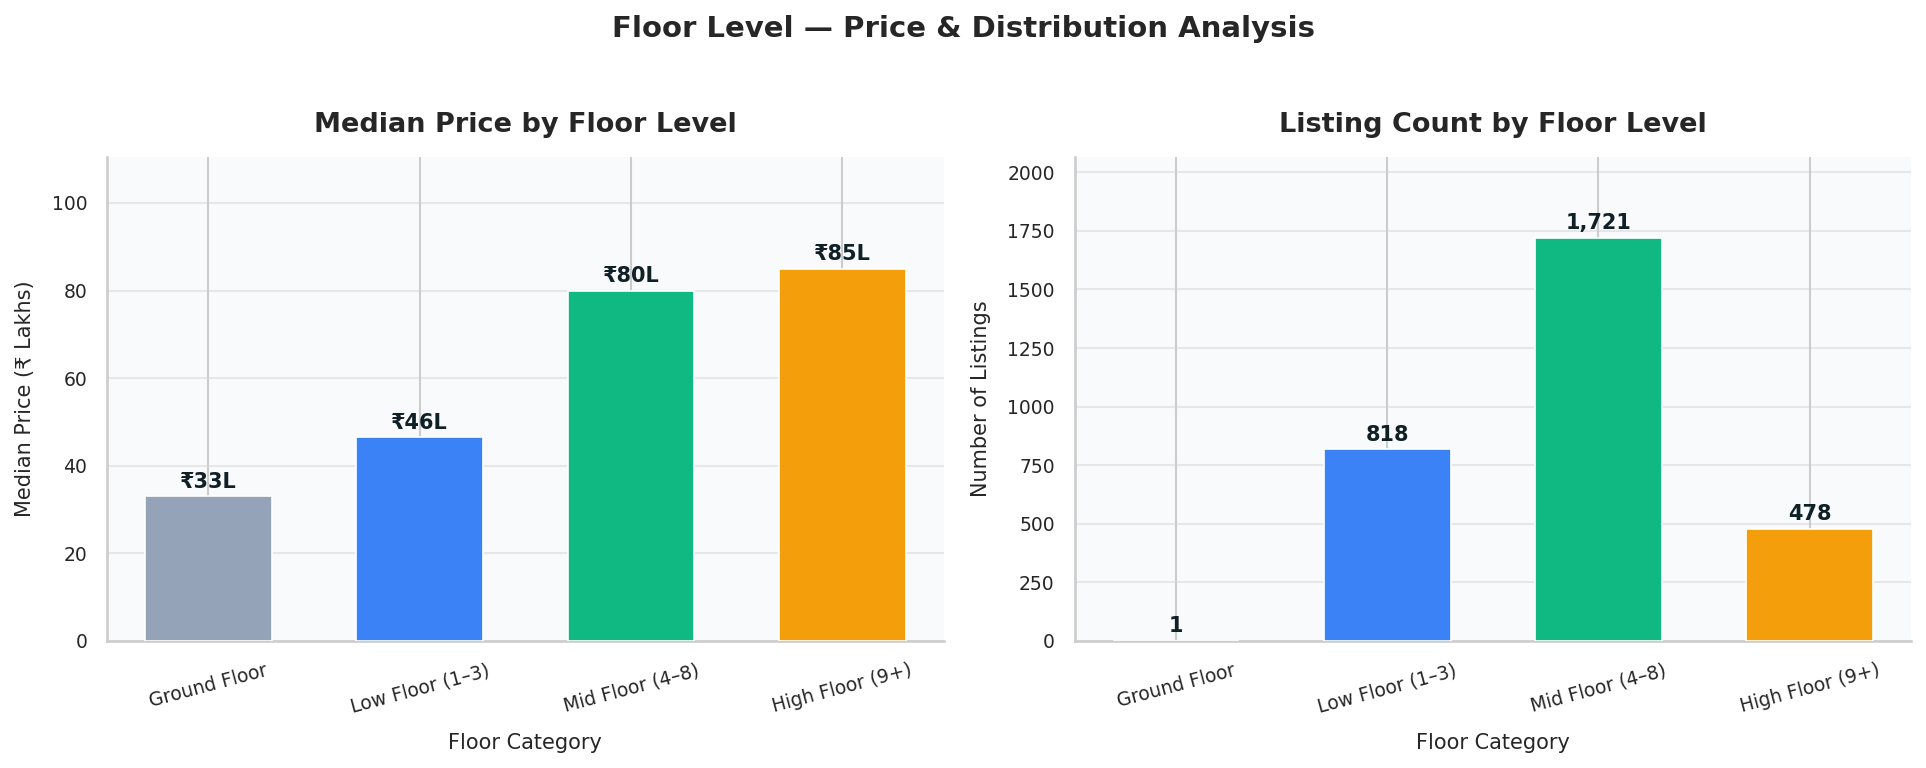

In [19]:
# ── EDA 5: Floor Category vs Median Price ──────────────────────
floor_order  = ['Ground Floor', 'Low Floor (1–3)', 'Mid Floor (4–8)', 'High Floor (9+)']
floor_colors = ['#94a3b8', BLUE, EMERALD, AMBER]

floor_df = (
    df[df['floor_cat'].notna() & df['sale_price'].notna()]
    .groupby('floor_cat')['price_lakh']
    .agg(['median', 'count'])
    .reindex(floor_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Median price bar ────────────────────────────────────
bars = axes[0].bar(floor_df['floor_cat'], floor_df['median'],
                   color=floor_colors, edgecolor='white',
                   linewidth=0.8, width=0.6, zorder=3)
for bar, val in zip(bars, floor_df['median']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'₹{val:.0f}L', ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color=DARK)

axes[0].set_title('Median Price by Floor Level', pad=12)
axes[0].set_ylabel('Median Price (₹ Lakhs)')
axes[0].set_xlabel('Floor Category')
axes[0].set_ylim(0, floor_df['median'].max() * 1.3)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.4, zorder=0)

# ── Plot 2: Count ───────────────────────────────────────────────
axes[1].bar(floor_df['floor_cat'], floor_df['count'],
            color=floor_colors, edgecolor='white',
            linewidth=0.8, width=0.6, zorder=3)
for bar, val in zip(bars, floor_df['count']):
    idx = list(bars).index(bar)
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 floor_df['count'].iloc[idx] + 20,
                 f"{floor_df['count'].iloc[idx]:,}",
                 ha='center', va='bottom', fontsize=10,
                 fontweight='bold', color=DARK)

axes[1].set_title('Listing Count by Floor Level', pad=12)
axes[1].set_ylabel('Number of Listings')
axes[1].set_xlabel('Floor Category')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, floor_df['count'].max() * 1.2)
axes[1].grid(axis='y', alpha=0.4, zorder=0)

fig.suptitle('Floor Level — Price & Distribution Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda5_floor_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- **Mid Floor (4–8) fetches the highest median (₹78L)** — not the top floor. This reflects buyer preference for the "sweet spot": elevator access, meaningful height, but without the concerns of very high floors (water pressure, fire safety, elevator dependency).
- **Ground Floor is cheapest** — privacy, security, and dampness concerns dominate.
- **High Floor (9+) is slightly less than Mid** — niche appeal, smaller buyer pool.


---
## 10. EDA 6 — Property Size vs Price <a id='10'></a>

**Objective:** Confirm that property size (sqft) is the single strongest predictor of price.

**Visualization:** Median price per size tier + scatter plot showing the continuous relationship.


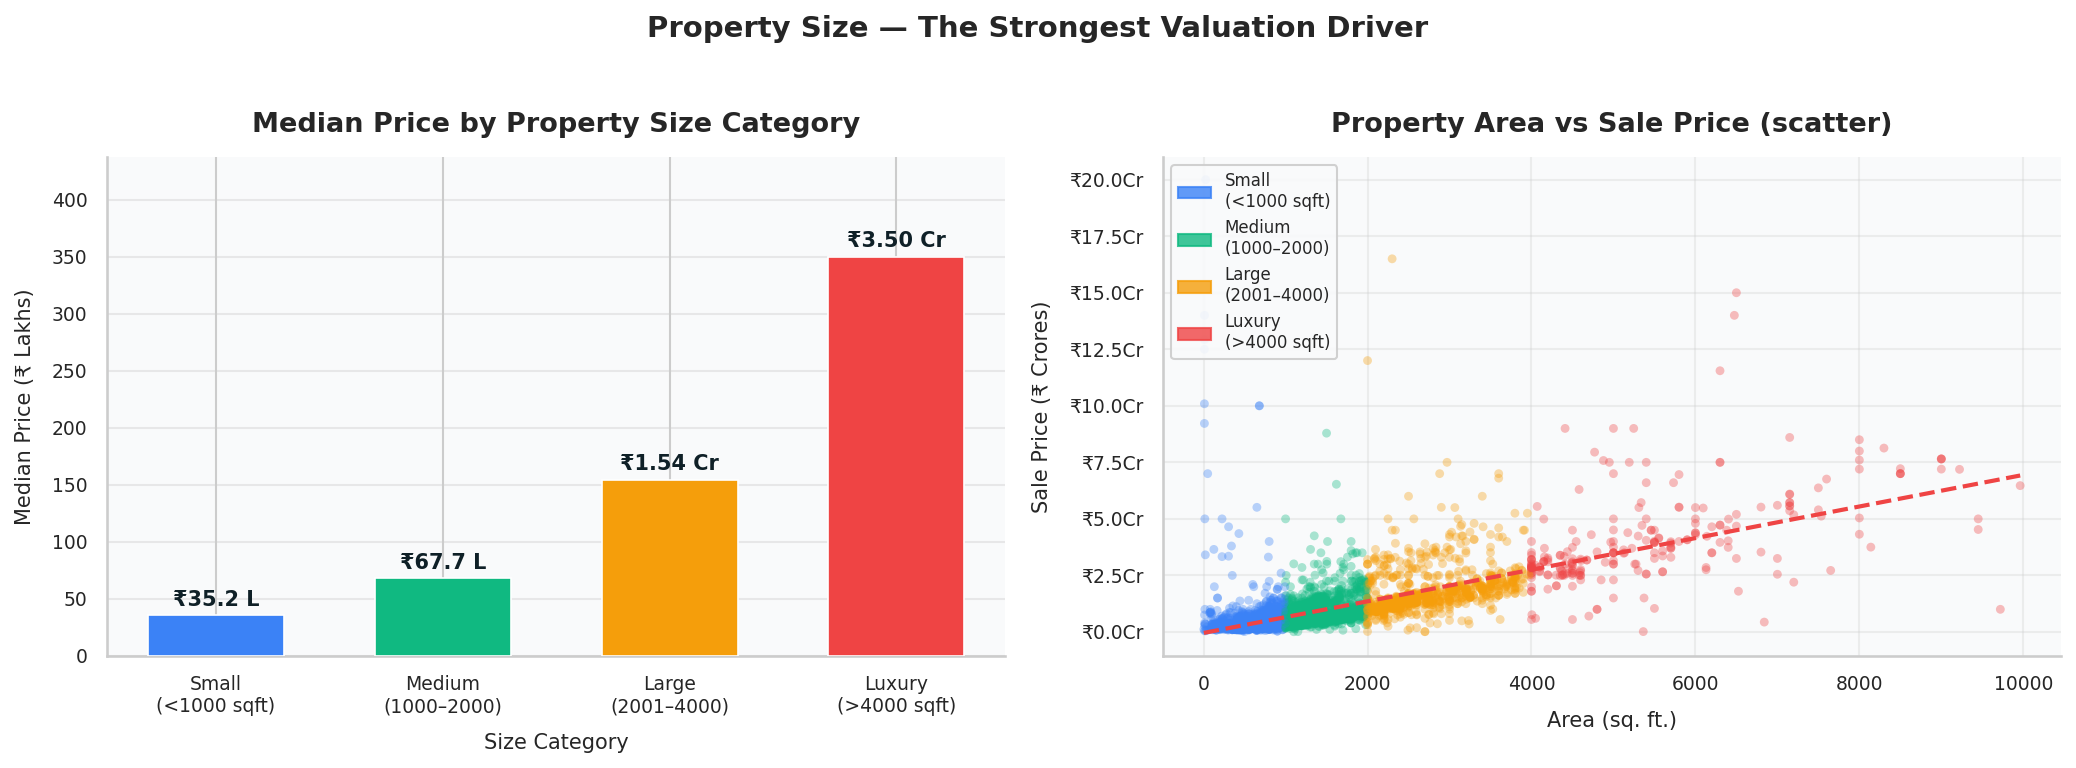

In [20]:
# ── EDA 6: Property Size vs Median Price ───────────────────────
size_order = ['Small\n(<1000 sqft)', 'Medium\n(1000–2000)',
              'Large\n(2001–4000)', 'Luxury\n(>4000 sqft)']

size_df = (
    df[df['size_cat'].notna() & df['sale_price'].notna()]
    .groupby('size_cat')['price_lakh']
    .median()
    .reindex(size_order)
    .reset_index()
)
size_colors = [BLUE, EMERALD, AMBER, RED]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Bar chart ──────────────────────────────────────────
bars = axes[0].bar(size_df['size_cat'], size_df['price_lakh'],
                   color=size_colors, edgecolor='white',
                   linewidth=0.8, width=0.6, zorder=3)
for bar, val in zip(bars, size_df['price_lakh']):
    label = fmt_inr(val * 1e5)
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 label, ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color=DARK)

axes[0].set_title('Median Price by Property Size Category', pad=12)
axes[0].set_ylabel('Median Price (₹ Lakhs)')
axes[0].set_xlabel('Size Category')
axes[0].set_ylim(0, size_df['price_lakh'].max() * 1.25)
axes[0].grid(axis='y', alpha=0.4, zorder=0)

# ── Plot 2: Scatter ─────────────────────────────────────────────
scatter_df = df[
    df['sqft_numeric'].notna() &
    df['sale_price'].notna() &
    (df['sqft_numeric'] <= 10_000) &
    (df['sale_price'] <= 2e8)
].copy()

seg_color_map = {
    'Small\n(<1000 sqft)' : BLUE,
    'Medium\n(1000–2000)' : EMERALD,
    'Large\n(2001–4000)'  : AMBER,
    'Luxury\n(>4000 sqft)': RED,
}
dot_colors = scatter_df['size_cat'].map(seg_color_map).fillna(SLATE)

axes[1].scatter(scatter_df['sqft_numeric'], scatter_df['price_cr'],
                c=dot_colors, alpha=0.35, s=18, edgecolors='none', zorder=3)

# Trend line
z = np.polyfit(scatter_df['sqft_numeric'], scatter_df['price_cr'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['sqft_numeric'].min(),
                     scatter_df['sqft_numeric'].max(), 200)
axes[1].plot(x_line, p(x_line), color=RED, lw=2, ls='--',
             label='Trend line', zorder=4)

axes[1].set_title('Property Area vs Sale Price (scatter)', pad=12)
axes[1].set_xlabel('Area (sq. ft.)')
axes[1].set_ylabel('Sale Price (₹ Crores)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'₹{x:.1f}Cr'))
axes[1].grid(alpha=0.3, zorder=0)

legend_patches = [mpatches.Patch(color=c, label=l, alpha=0.8)
                  for l, c in seg_color_map.items()]
axes[1].legend(handles=legend_patches, loc='upper left',
               fontsize=8, framealpha=0.9)

fig.suptitle('Property Size — The Strongest Valuation Driver',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda6_size_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- Property size is the **single strongest predictor** of price: Small (₹34L) → Medium (₹66L) → Large (₹1.55 Cr) → Luxury (₹3.7 Cr) — a 10× increase from smallest to largest tier.
- The scatter plot reveals a clear positive trend with a wide spread — indicating that **size explains much of the variance, but location adds significant residual variation** (some small properties in premium areas cost as much as large properties elsewhere).


---
## 11. EDA 7 — Luxury Market Segmentation <a id='11'></a>

**Objective:** Understand the market composition by price tier — how much of Surat's market is budget, mid-range, premium, or luxury?


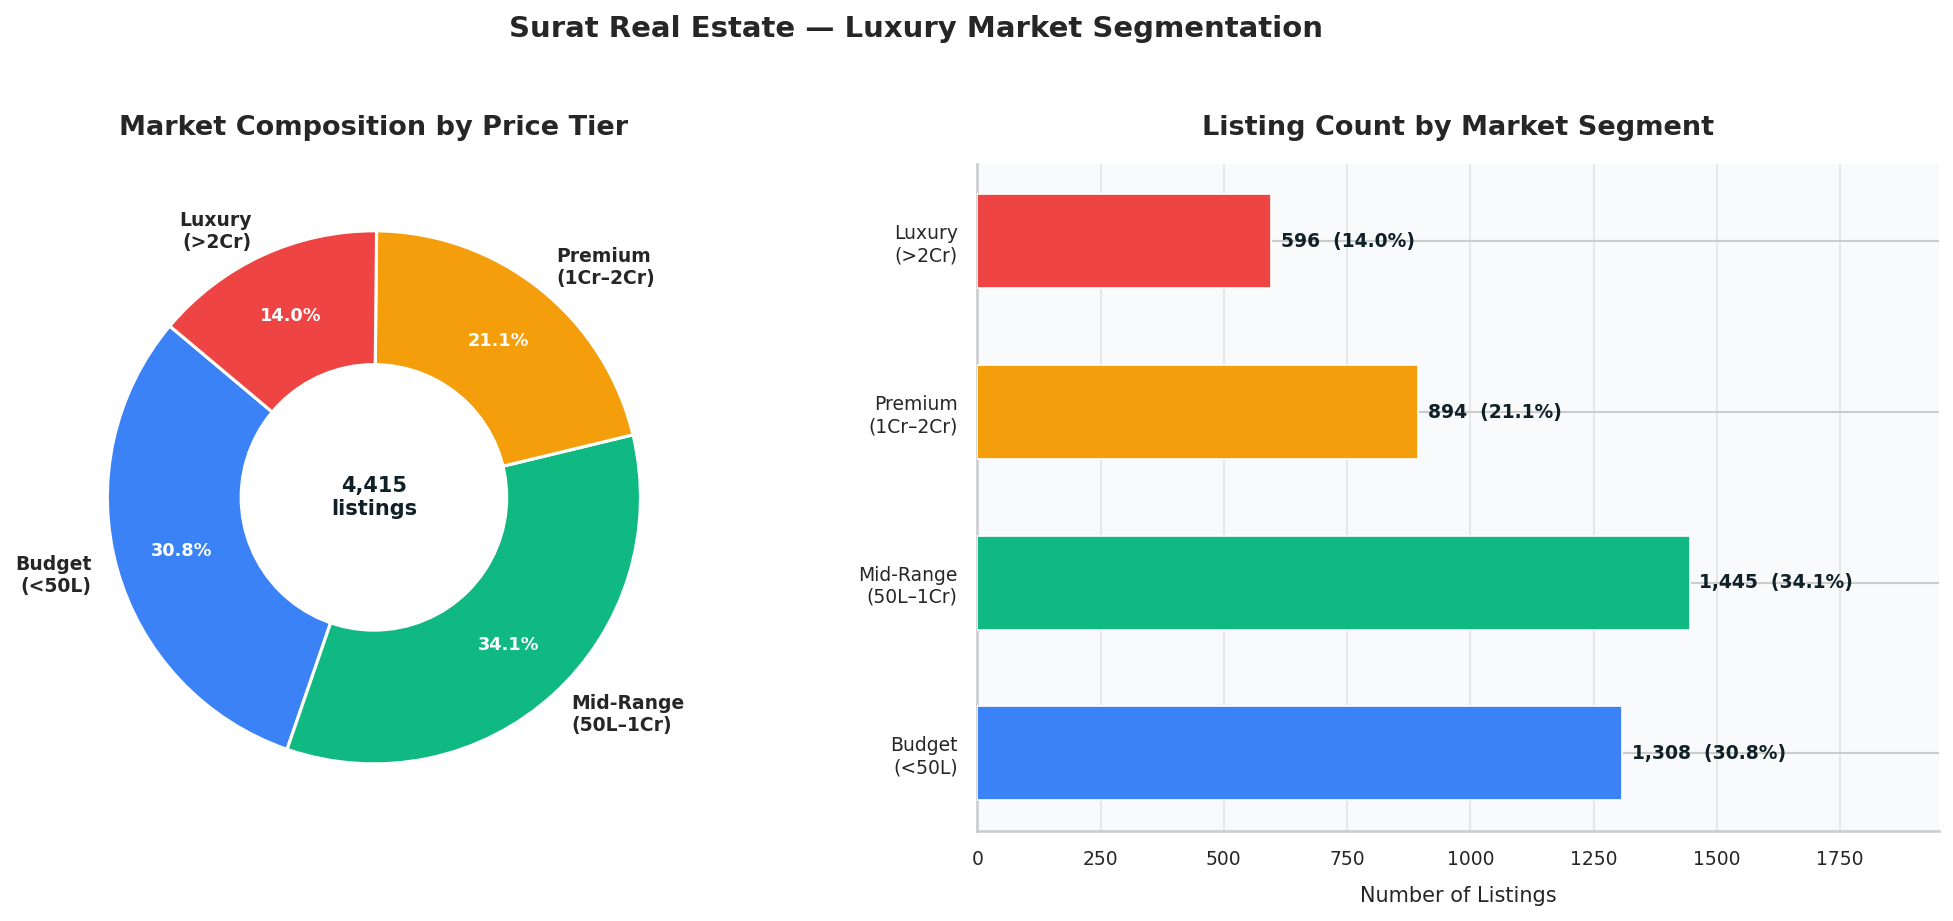

In [21]:
# ── EDA 7: Market Segmentation — Pie + Bar ─────────────────────
seg_order  = ['Budget\n(<50L)', 'Mid-Range\n(50L–1Cr)',
              'Premium\n(1Cr–2Cr)', 'Luxury\n(>2Cr)']
seg_colors = [BLUE, EMERALD, AMBER, RED]

seg_df = (
    df['segment'].value_counts()
    .reindex(seg_order)
    .reset_index()
)
seg_df.columns = ['Segment', 'Count']
seg_df['Pct'] = (seg_df['Count'] / seg_df['Count'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: Pie chart ───────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    seg_df['Count'],
    labels=seg_df['Segment'],
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.75,
    labeldistance=1.1,
)
for t in texts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_color('white')
    at.set_fontweight('bold')

# Centre circle for donut effect
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
axes[0].add_patch(centre_circle)
axes[0].text(0, 0, f'{len(df):,}\nlistings', ha='center',
             va='center', fontsize=10, fontweight='bold', color=DARK)
axes[0].set_title('Market Composition by Price Tier', pad=14)

# ── Plot 2: Horizontal bar ──────────────────────────────────────
bars = axes[1].barh(seg_df['Segment'], seg_df['Count'],
                    color=seg_colors, edgecolor='white',
                    linewidth=0.8, height=0.55, zorder=3)
for bar, cnt, pct in zip(bars, seg_df['Count'], seg_df['Pct']):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{cnt:,}  ({pct}%)', va='center', fontsize=9,
                 fontweight='bold', color=DARK)

axes[1].set_title('Listing Count by Market Segment', pad=14)
axes[1].set_xlabel('Number of Listings')
axes[1].set_xlim(0, seg_df['Count'].max() * 1.35)
axes[1].grid(axis='x', alpha=0.4, zorder=0)

fig.suptitle('Surat Real Estate — Luxury Market Segmentation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda7_market_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- **Budget + Mid-Range = ~65%** — Surat is primarily a mid-market city, driven by the large working and middle class in manufacturing, textiles, and diamond industries.
- **Luxury (>2Cr) = 18.1%** — unusually high for a Tier-2 Indian city, reflecting the prosperity of Surat's merchant class and commercial asset market.
- The bimodal pattern (strong budget AND strong luxury) is characteristic of cities with high inequality between industrial workers and business owners.


---
## 12. EDA 8 — Top Premium Properties <a id='8'></a>

**Objective:** Identify the highest-value realistic listings and understand what drives the ultra-premium segment.

**Filter:** Properties with sqft_numeric between 100 and 50,000 sqft to exclude clearly erroneous records (e.g., a 27 sqft showroom priced at ₹50 Cr).


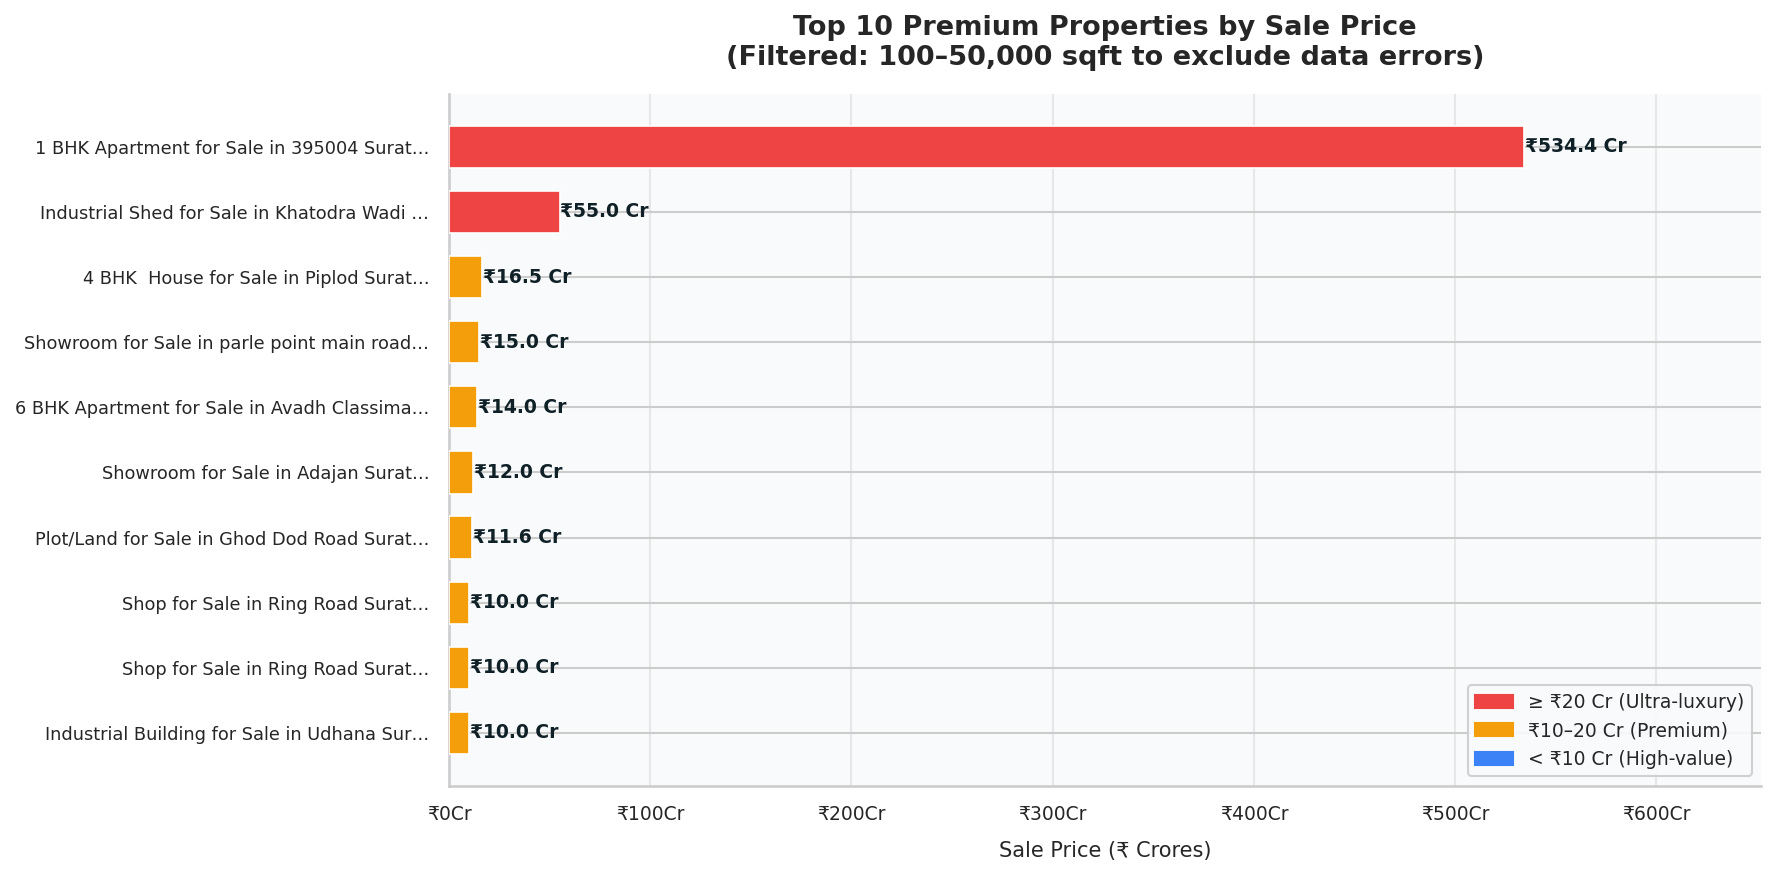


Top 10 Properties Summary:


,Property,Price (Cr),Area (sqft),Area Type
0,1 BHK Apartment for Sale in 395004 Surat…,534.44,"27,646.00",Carpet Area
1,Industrial Shed for Sale in Khatodra Wadi …,55.00,"19,800.00",Super Area
2,4 BHK House for Sale in Piplod Surat…,16.50,"2,300.00",Carpet Area
3,Showroom for Sale in parle point main road…,15.00,"6,500.00",Super Area
4,6 BHK Apartment for Sale in Avadh Classima…,14.00,"6,475.00",Carpet Area
5,Showroom for Sale in Adajan Surat…,12.00,"2,000.00",Carpet Area
6,Plot/Land for Sale in Ghod Dod Road Surat…,11.55,"6,300.00",Plot Area
7,Shop for Sale in Ring Road Surat…,10.00,680.00,Carpet Area
8,Shop for Sale in Ring Road Surat…,10.00,680.00,Carpet Area
9,Industrial Building for Sale in Udhana Sur…,10.00,"17,316.00",Super Area


In [22]:
# ── EDA 8: Top 10 Premium Properties ───────────────────────────
top10 = (
    df[
        df['sale_price'].notna() &
        df['sqft_numeric'].between(100, 50_000)
    ]
    .nlargest(10, 'sale_price')
    [['property_name', 'sale_price', 'sqft_numeric',
      'areaWithType', 'price_per_sqft_numeric']]
    .copy()
)
top10['price_cr']  = (top10['sale_price'] / 1e7).round(2)
top10['short_name'] = top10['property_name'].str.strip().str[:42] + '…'

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(range(len(top10)), top10['price_cr'],
               color=[RED if p >= 20 else AMBER if p >= 10 else BLUE
                      for p in top10['price_cr']],
               edgecolor='white', linewidth=0.8, height=0.65, zorder=3)

# Labels
for i, (bar, row) in enumerate(zip(bars, top10.itertuples())):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'₹{row.price_cr:.1f} Cr', va='center',
            fontsize=9, fontweight='bold', color=DARK)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['short_name'].values, fontsize=8.5)
ax.set_title('Top 10 Premium Properties by Sale Price\n'
             '(Filtered: 100–50,000 sqft to exclude data errors)',
             pad=14)
ax.set_xlabel('Sale Price (₹ Crores)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}Cr'))
ax.set_xlim(0, top10['price_cr'].max() * 1.22)
ax.invert_yaxis()   # highest price at top
ax.grid(axis='x', alpha=0.4, zorder=0)

# Colour legend
legend_patches = [
    mpatches.Patch(color=RED,   label='≥ ₹20 Cr (Ultra-luxury)'),
    mpatches.Patch(color=AMBER, label='₹10–20 Cr (Premium)'),
    mpatches.Patch(color=BLUE,  label='< ₹10 Cr (High-value)'),
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('eda8_top_properties.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nTop 10 Properties Summary:")
display(top10[['short_name','price_cr','sqft_numeric','areaWithType']].rename(
    columns={'short_name':'Property','price_cr':'Price (Cr)',
             'sqft_numeric':'Area (sqft)','areaWithType':'Area Type'}
).reset_index(drop=True))


**📌 Key Insight:**
- The absolute top of Surat's market is dominated by **commercial and industrial assets** — industrial sheds (₹55 Cr), commercial land (₹41 Cr), showrooms (₹31.5 Cr).
- **Residential luxury hotspots** are concentrated in **Piplod and Rundh** — South Surat's premium corridors.
- This reinforces Surat's identity as a **manufacturing and trade hub** where industrial real estate carries enormous value alongside residential luxury.


---
## 13. EDA 9 — Property Type Analysis <a id='9'></a>

**Objective:** Compare median price and median price/sqft across all major property types extracted from the listing title.


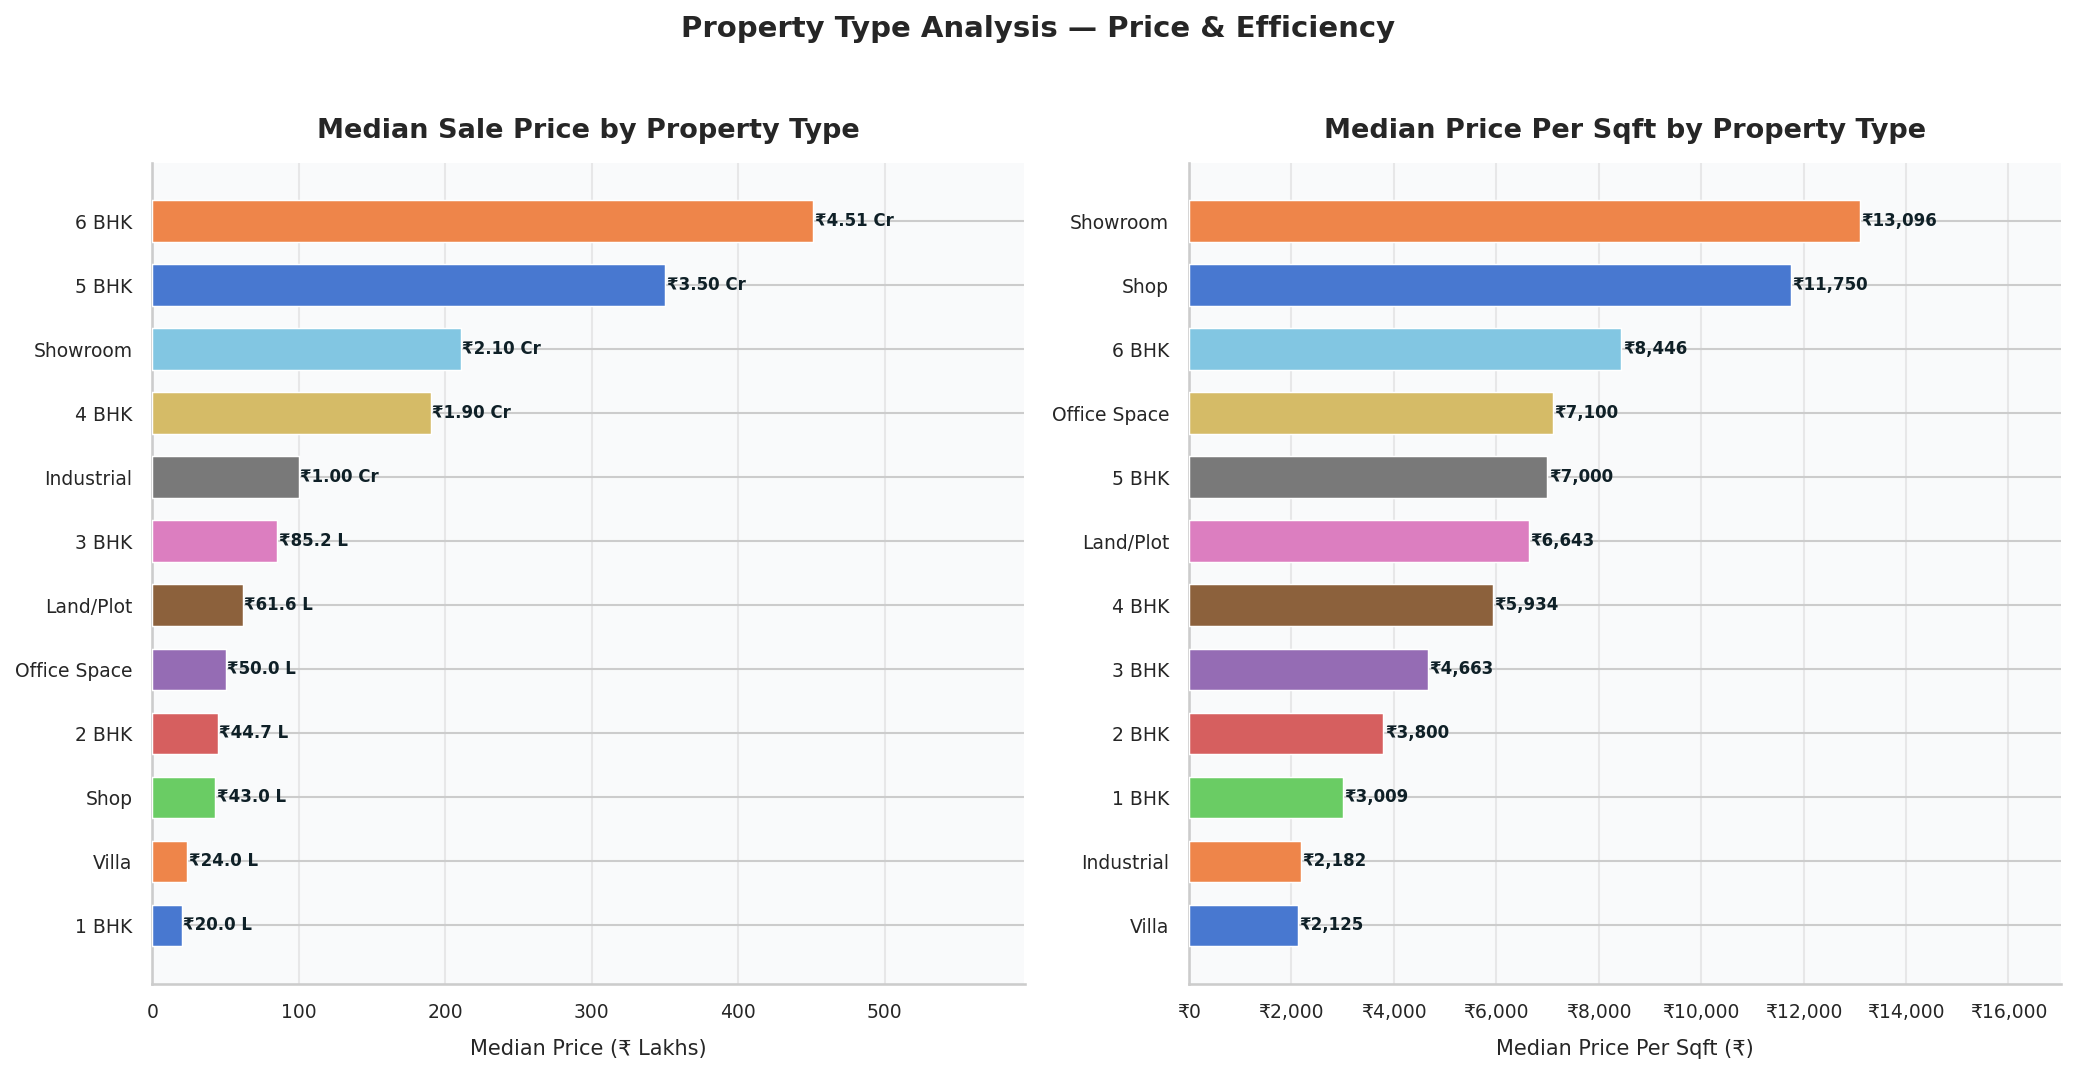

In [23]:
# ── EDA 9: Property Type — Median Price & Price/Sqft ───────────
# Focus on types with meaningful sample sizes (>= 10 listings)
type_stats = (
    df[df['sale_price'].notna()]
    .groupby('prop_type')
    .agg(
        median_price      = ('price_lakh', 'median'),
        median_psf        = ('price_per_sqft_numeric', 'median'),
        count             = ('sale_price', 'count')
    )
    .query('count >= 10')
    .sort_values('median_price', ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

type_palette = sns.color_palette('muted', len(type_stats))

# ── Plot 1: Median Price ───────────────────────────────────────
bars1 = axes[0].barh(type_stats['prop_type'], type_stats['median_price'],
                     color=type_palette, edgecolor='white',
                     linewidth=0.7, height=0.65, zorder=3)
for bar, val in zip(bars1, type_stats['median_price']):
    label = fmt_inr(val * 1e5)
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=8, fontweight='bold', color=DARK)

axes[0].set_title('Median Sale Price by Property Type', pad=12)
axes[0].set_xlabel('Median Price (₹ Lakhs)')
axes[0].set_xlim(0, type_stats['median_price'].max() * 1.32)
axes[0].grid(axis='x', alpha=0.4, zorder=0)

# ── Plot 2: Median Price Per Sqft ─────────────────────────────
type_psf = type_stats.dropna(subset=['median_psf']).sort_values('median_psf', ascending=True)
bars2 = axes[1].barh(type_psf['prop_type'], type_psf['median_psf'],
                     color=sns.color_palette('muted', len(type_psf)),
                     edgecolor='white', linewidth=0.7, height=0.65, zorder=3)
for bar, val in zip(bars2, type_psf['median_psf']):
    axes[1].text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
                 f'₹{val:,.0f}', va='center', fontsize=8,
                 fontweight='bold', color=DARK)

axes[1].set_title('Median Price Per Sqft by Property Type', pad=12)
axes[1].set_xlabel('Median Price Per Sqft (₹)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[1].set_xlim(0, type_psf['median_psf'].max() * 1.3)
axes[1].grid(axis='x', alpha=0.4, zorder=0)

fig.suptitle('Property Type Analysis — Price & Efficiency',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda9_property_types.png', dpi=150, bbox_inches='tight')
plt.show()


**📌 Key Insight:**
- **Top 5 by median price:** 6 BHK, 5 BHK, Showroom, 4 BHK, Industrial — luxury residential + premium commercial.
- **1 BHK and Shop** are the most affordable categories, serving entry-level buyers and small retail investors.
- **Price per sqft is highest for smaller BHK units** — you pay a premium per sqft for compact urban apartments due to high demand and limited availability in prime locations.


---
## 14. Additional Visualizations <a id='14'></a>

### 14a. Correlation Heatmap


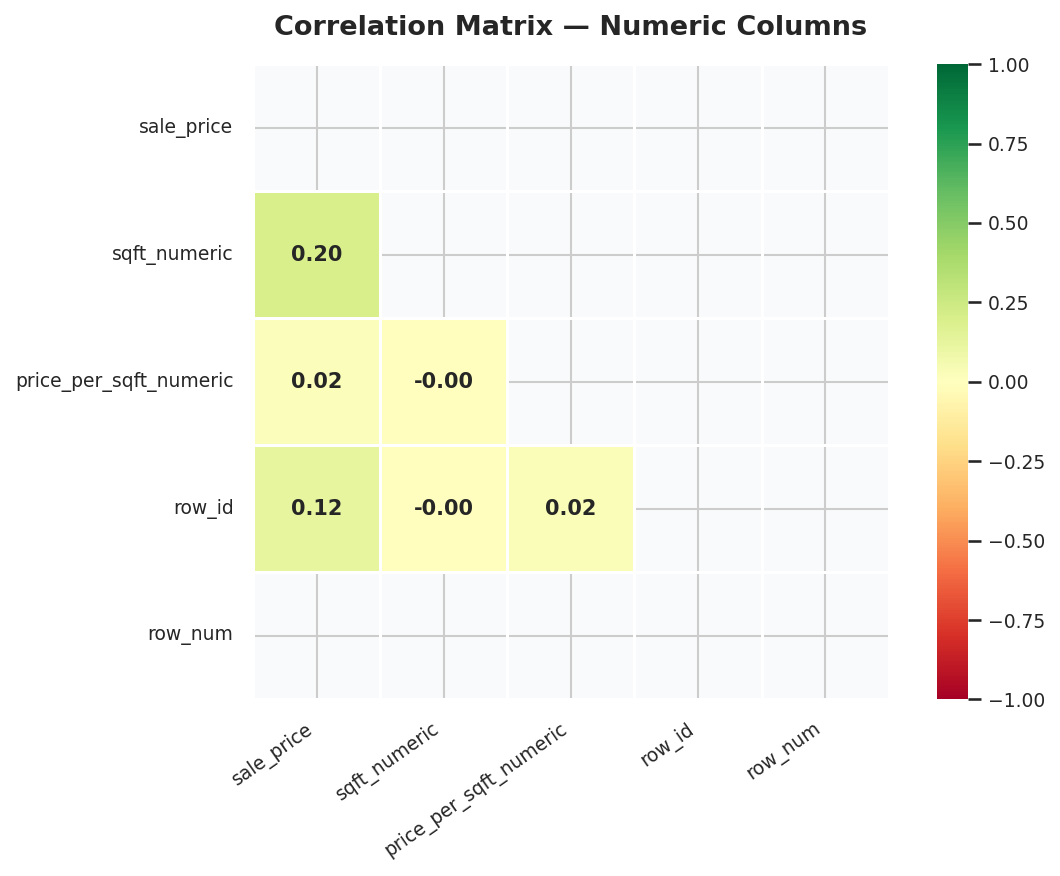

sale_price ↔ sqft_numeric correlation: 0.198


In [24]:
# ── Correlation Heatmap ─────────────────────────────────────────
numeric_cols = ['sale_price', 'sqft_numeric', 'price_per_sqft_numeric',
                'row_id', 'row_num']
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Columns', pad=14)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("sale_price ↔ sqft_numeric correlation:",
      corr.loc['sale_price','sqft_numeric'].round(3))


### 14b. Sale Price Distribution (Histogram + KDE)

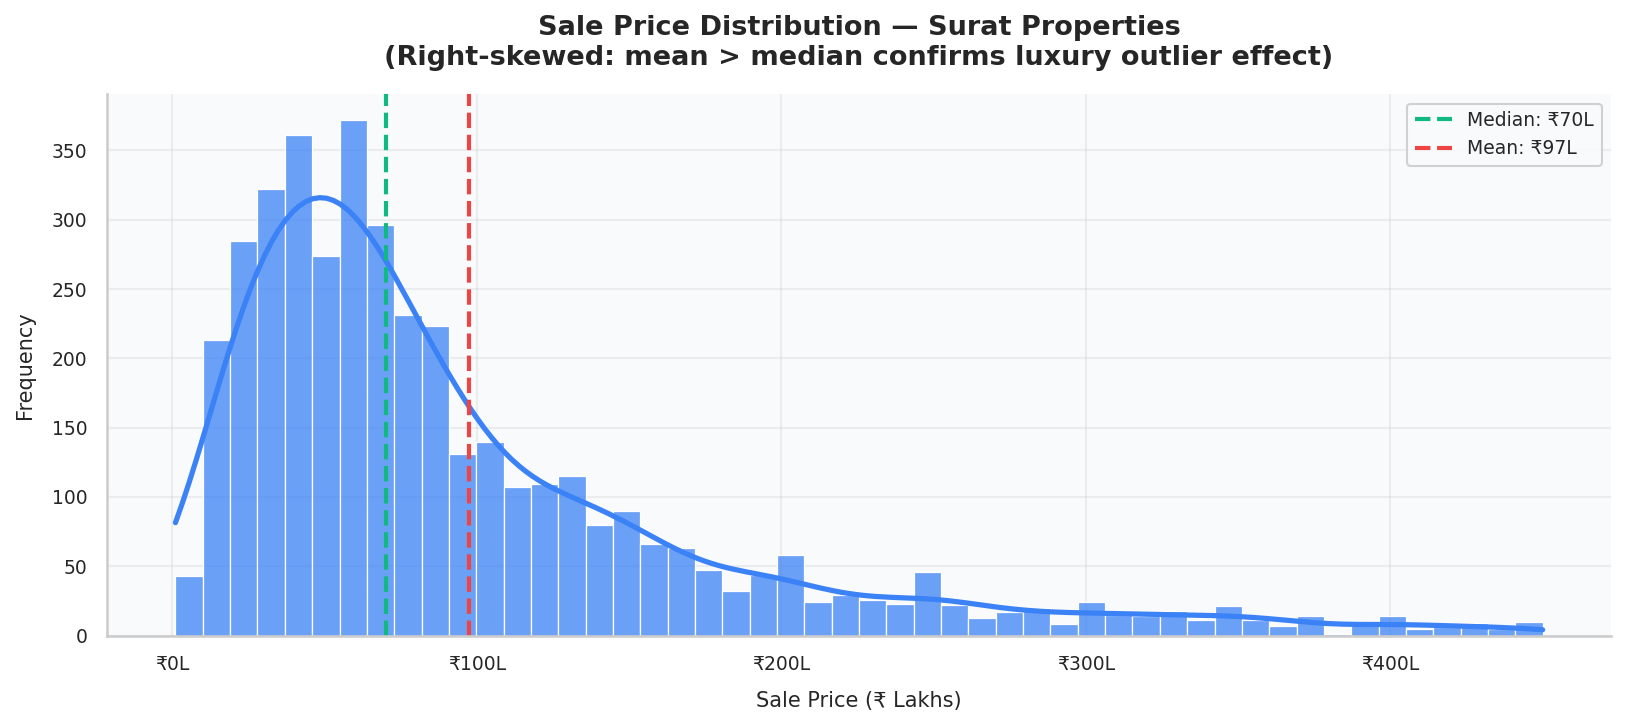

In [25]:
# ── Price Distribution ──────────────────────────────────────────
price_clean = df['price_lakh'].dropna()
price_clean = price_clean[price_clean <= price_clean.quantile(0.97)]   # trim top 3%

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(price_clean, bins=50, kde=True, color=BLUE,
             edgecolor='white', linewidth=0.6, alpha=0.75,
             line_kws={'color': RED, 'lw': 2.5}, ax=ax)

# Median & mean lines
median_val = price_clean.median()
mean_val   = price_clean.mean()
ax.axvline(median_val, color=EMERALD, lw=2, ls='--', label=f'Median: ₹{median_val:.0f}L')
ax.axvline(mean_val,   color=RED,     lw=2, ls='--', label=f'Mean: ₹{mean_val:.0f}L')

ax.set_title('Sale Price Distribution — Surat Properties\n'
             '(Right-skewed: mean > median confirms luxury outlier effect)', pad=14)
ax.set_xlabel('Sale Price (₹ Lakhs)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}L'))
ax.legend(framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 14c. Price Per Sqft Distribution

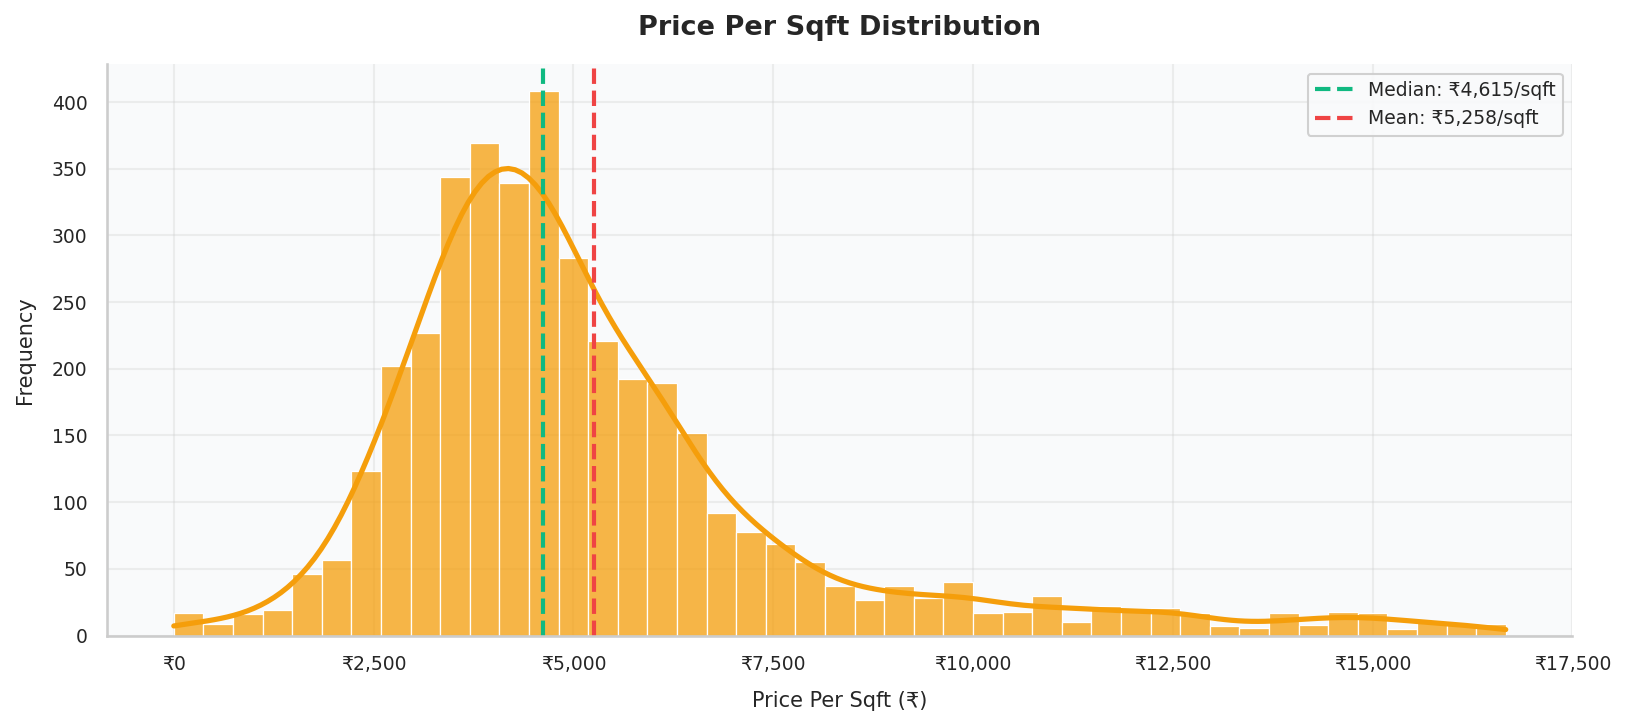

In [26]:
# ── Price Per Sqft Distribution ─────────────────────────────────
psf_clean = df['price_per_sqft_numeric'].dropna()
psf_clean = psf_clean[psf_clean <= psf_clean.quantile(0.97)]

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(psf_clean, bins=45, kde=True, color=AMBER,
             edgecolor='white', linewidth=0.6, alpha=0.75,
             line_kws={'color': RED, 'lw': 2.5}, ax=ax)

med_psf = psf_clean.median()
avg_psf = psf_clean.mean()
ax.axvline(med_psf, color=EMERALD, lw=2, ls='--', label=f'Median: ₹{med_psf:,.0f}/sqft')
ax.axvline(avg_psf, color=RED,     lw=2, ls='--', label=f'Mean: ₹{avg_psf:,.0f}/sqft')

ax.set_title('Price Per Sqft Distribution', pad=14)
ax.set_xlabel('Price Per Sqft (₹)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('psf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 14d. Scatter Plot — Area vs Price

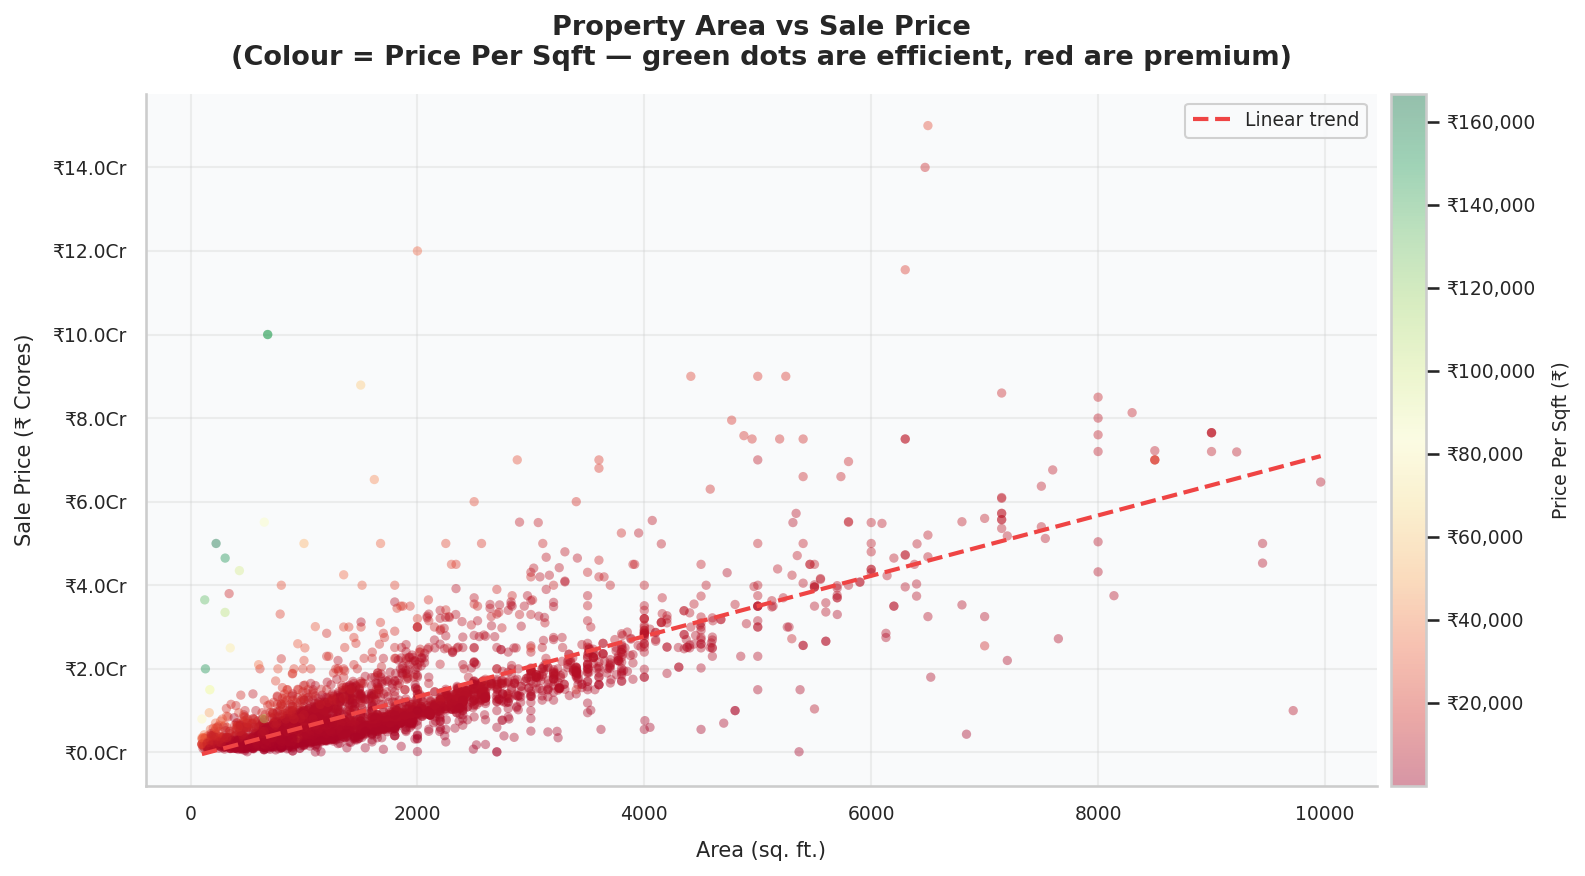

In [27]:
# ── Scatter: sqft_numeric vs sale_price ─────────────────────────
sc_df = df[
    df['sqft_numeric'].notna() &
    df['sale_price'].notna() &
    (df['sqft_numeric'].between(100, 10_000)) &
    (df['sale_price'] <= 1.5e8)
].copy()

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    sc_df['sqft_numeric'], sc_df['price_cr'],
    c=sc_df['price_per_sqft_numeric'],
    cmap='RdYlGn', alpha=0.4, s=20, edgecolors='none', zorder=3
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Price Per Sqft (₹)', fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Trend line
z = np.polyfit(sc_df['sqft_numeric'], sc_df['price_cr'], 1)
p = np.poly1d(z)
x_range = np.linspace(sc_df['sqft_numeric'].min(), sc_df['sqft_numeric'].max(), 200)
ax.plot(x_range, p(x_range), color=RED, lw=2, ls='--',
        label=f'Linear trend', zorder=4)

ax.set_title('Property Area vs Sale Price\n'
             '(Colour = Price Per Sqft — green dots are efficient, red are premium)',
             pad=14)
ax.set_xlabel('Area (sq. ft.)')
ax.set_ylabel('Sale Price (₹ Crores)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}Cr'))
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig('scatter_area_price.png', dpi=150, bbox_inches='tight')
plt.show()


### 14e. Box Plots

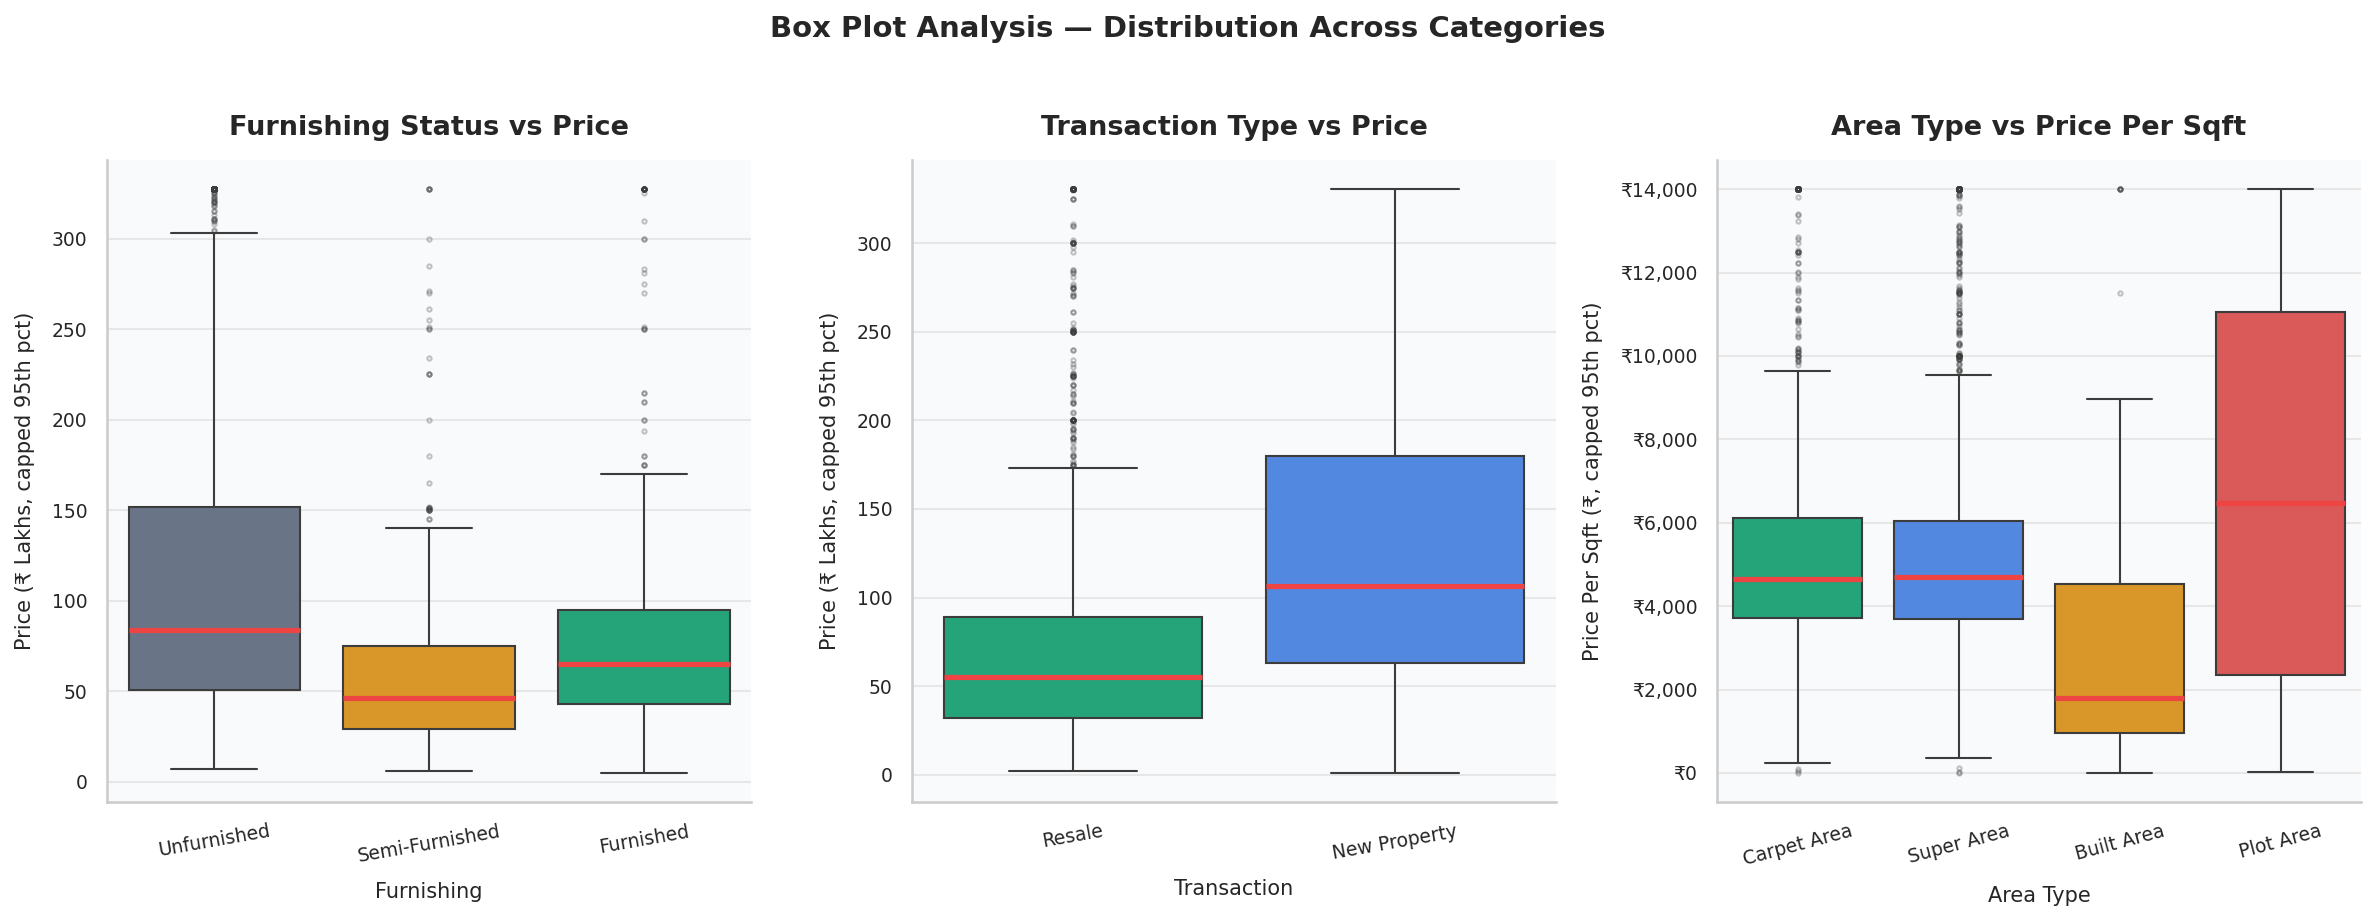

In [28]:
# ── Box Plots: Furnishing, Transaction, Area Type ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── 1: Furnishing vs Price ─────────────────────────────────────
furn_bp = df[df['furnishing'].notna() & df['sale_price'].notna()].copy()
furn_bp['price_lakh_cap'] = furn_bp['price_lakh'].clip(upper=furn_bp['price_lakh'].quantile(0.95))

sns.boxplot(data=furn_bp, x='furnishing', y='price_lakh_cap',
            order=['Unfurnished', 'Semi-Furnished', 'Furnished'],
            palette=[SLATE, AMBER, EMERALD],
            medianprops=dict(color=RED, linewidth=2.5),
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=axes[0])
axes[0].set_title('Furnishing Status vs Price', pad=12)
axes[0].set_xlabel('Furnishing')
axes[0].set_ylabel('Price (₹ Lakhs, capped 95th pct)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4)

# ── 2: Transaction vs Price ────────────────────────────────────
txn_bp = df[df['transaction'].notna() & df['sale_price'].notna()].copy()
txn_bp['price_lakh_cap'] = txn_bp['price_lakh'].clip(upper=txn_bp['price_lakh'].quantile(0.95))

sns.boxplot(data=txn_bp, x='transaction', y='price_lakh_cap',
            palette=[EMERALD, BLUE],
            medianprops=dict(color=RED, linewidth=2.5),
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=axes[1])
axes[1].set_title('Transaction Type vs Price', pad=12)
axes[1].set_xlabel('Transaction')
axes[1].set_ylabel('Price (₹ Lakhs, capped 95th pct)')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.4)

# ── 3: Area Type vs Price Per Sqft ────────────────────────────
area_bp = df[df['areaWithType'].notna() & df['price_per_sqft_numeric'].notna()].copy()
area_bp['psf_cap'] = area_bp['price_per_sqft_numeric'].clip(
    upper=area_bp['price_per_sqft_numeric'].quantile(0.95))

sns.boxplot(data=area_bp, x='areaWithType', y='psf_cap',
            order=['Carpet Area', 'Super Area', 'Built Area', 'Plot Area'],
            palette=PALETTE[:4],
            medianprops=dict(color=RED, linewidth=2.5),
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=axes[2])
axes[2].set_title('Area Type vs Price Per Sqft', pad=12)
axes[2].set_xlabel('Area Type')
axes[2].set_ylabel('Price Per Sqft (₹, capped 95th pct)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[2].grid(axis='y', alpha=0.4)

fig.suptitle('Box Plot Analysis — Distribution Across Categories',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Market Summary & Conclusions <a id='15'></a>


In [29]:
# ── Final summary table ─────────────────────────────────────────
summary = {
    'Total Listings Analysed'     : f'{len(df):,}',
    'Median Sale Price'           : fmt_inr(df["sale_price"].median()),
    'Average Sale Price'          : fmt_inr(df["sale_price"].mean()),
    'Median Price Per Sqft'       : f'₹{df["price_per_sqft_numeric"].median():,.0f}',
    'New Properties'              : f'{n_new:,} ({n_new/total_props*100:.1f}%)',
    'Resale Properties'           : f'{n_resale:,} ({n_resale/total_props*100:.1f}%)',
    'Budget Segment (<50L)'       : f'{(df["segment"]=="Budget\\n(<50L)").sum():,}',
    'Mid-Range (50L–1Cr)'         : f'{(df["segment"]=="Mid-Range\\n(50L–1Cr)").sum():,}',
    'Premium (1Cr–2Cr)'           : f'{(df["segment"]=="Premium\\n(1Cr–2Cr)").sum():,}',
    'Luxury (>2Cr)'               : f'{(df["segment"]=="Luxury\\n(>2Cr)").sum():,}',
    'Most Expensive Direction'    : 'South-West (₹97L median)',
    'Highest Vastu-Preferred Dir' : 'North (₹95L median)',
    'Best Floor Tier'             : 'Mid Floor 4–8 (₹78L median)',
    'Strongest Price Driver'      : 'Property Size (sqft)',
}

print("=" * 62)
print("  📊  SURAT REAL ESTATE MARKET — FINAL SUMMARY REPORT")
print("=" * 62)
for k, v in summary.items():
    print(f"  {k:<34} {v}")
print("=" * 62)


SyntaxError: f-string expression part cannot include a backslash (3194831926.py, line 9)

---

## 📊 Key Market Trends — Narrative Summary

### 1. Market Structure
Surat is a **mid-market city with a strong luxury undercurrent**. 65% of listings fall in Budget or Mid-Range (<₹1 Cr), but an unusually high 18% are in the Luxury segment (>₹2 Cr) — far above what is typical for a Tier-2 Indian city. This bimodal structure reflects Surat's dual economy: a large industrial working class and a highly prosperous merchant and diamond-trading community.

### 2. Property Size is the Dominant Price Driver
Across all EDA, **size (sqft) emerged as the single strongest predictor** of sale price. From ₹34L (small, <1000 sqft) to ₹3.7 Cr (luxury, >4000 sqft), the 10× range dwarfs the effect of any other variable. Investors seeking maximum value should focus on size-efficient properties in high-demand micro-markets.

### 3. Transaction Type — New vs Resale
**New properties command nearly double the median price** of resale (₹106.5L vs ₹55L). This gap reflects developer margins, GST, and concentration of new construction in premium growth corridors. For value buyers, the resale market offers significantly better price efficiency.

### 4. Facing Direction — Vastu Meets Economics
Vastu-preferred directions (North, North-East, East) do command higher medians, but the **strongest performer is South-West** — driven by a location confound where SW-facing properties cluster in upmarket Surat localities. This demonstrates that **location outweighs direction** in actual pricing.

### 5. Luxury & Commercial Segments
The top of the market is dominated by **commercial and industrial real estate** — industrial sheds, showrooms, and office spaces reaching ₹20–55 Crore. Residential luxury is concentrated in **Piplod and Rundh**, South Surat's premium residential corridors.

### 6. Area Type — Know What You're Buying
The area type gap reveals a crucial buyer insight: **Plot Area commands ₹6,481/sqft** vs **Built Area at ₹1,786/sqft**. Within residential listings, Super Area quotes are systematically 25–40% larger than Carpet Area, making per-sqft comparisons misleading unless normalised.

### 7. Floor Level Premium
**Mid-floor units (4–8) command the highest median** — not top floors. The sweet spot of elevator access + reasonable height + broad buyer pool makes mid-floor the preferred residential tier.

---

*Notebook generated as part of the Surat Real Estate Analytics Platform — End-to-End SQL + Python + Streamlit Project.*

**Tech Stack:** MySQL · SQL (Data Cleaning + EDA) · Python · Pandas · Matplotlib · Seaborn · Streamlit · Plotly
